# Case Study: Ocean Health Indicators in Folger Passage

For the best learning experience please work through the Python Tutorial notebook before starting this one\. If you have previous programming experience in python and familiarity with pandas, you may be able to skip the tutorial\. 

In this coding notebook we will combine real\-world data science with ocean monitoring to explore the health of the local ecosystem\. In this case study, we’ll focus on Folger Passage, located in the Bamfield region on the west coast of Vancouver Island, within Huu\-ay\-aht ḥahuułi \(territory\)\. See the map below to situate yourself in this region\. This area is home to two key Ocean Networks Canada \(ONC\) observatories: Folger Deep \(location code: FGPD\) and Folger Pinnacle \(location code: FGPPN\)\. 

<img src="(3) Folger Passage 2021 files/folger_passage_overview.png" width="" align="" />

See the figures below for more information on the two major stations in Folgers Passage, Folger Deep and Folger Pinnacle\. Note one of the graphics displays the sensors available at each station while the other gives you a depth perspective using a profile view\. 

<img src="(3) Folger Passage 2021 files/folger_passage_sensors.png" width="" align="" />

Folger Passage overview, including the sensors available at Folger Deep and Folger Pinnacle\.

<img src="(3) Folger Passage 2021 files/folger_passage_bathymetry.jpg" width="" align="" />

A profile view of the Folger Deep and Folger Pinnacle stations, giving a perspective of the difference in depth between the two stations\.

## Oxygen Profile Offshore from Folger Passage

The following plot was created by combining a series of vertical casts \(18 August 2021\) from offshore \(near 400 m deep\) to inshore \(100 m deep\)\. You can see the locations of the casts as black dots on the map below\. Looking at the section of dissolved oxygen \(DO\), notice the very low oxygen values indicated by purple shades with the red 1\.4 mL/L contour\. We're going to investigate whether ONC's data shows similar trends, and how those change by time of year\.

<img src="(3) Folger Passage 2021 files/oxygen_profile_plots.jpeg" width="" align="" />

A set of plots showing dissolved oxygen and depth off the coast of Vancouver Island, as well as pressure and temperature\. Data from ONC, plot courtesy of Steve Mihaly\.

## Workshop Outline

Using ONC data, you’ll learn how to programmatically access and work with oceanographic data collected from these underwater stations\. We’ll walk through how to retrieve and visualize datasets, with a focus on a low oxygen event that occurred in August 2021\. This workbook was inspired by the work of Franco et al\., 2023 titled Drivers and Potential Consequences of Observed Extreme Hypoxia Along the Canadian Pacific Continental Shelf \(https://doi\.org/10\.1029/2022GL101857\)\. This is a key local example of how environmental events can be detected and interpreted using real\-time ocean data\.

Another unique event during this time was an unprecedented heatwave across the Pacific Northwest, which is visible in this data\. Information about the heatwave comes from White et al, 2023 \(https://doi\.org/10\.1038/s41467\-023\-36289\-3\)

We're going to investigate several data types and events today:

- Oxygen and hypoxia

- Chlorophyll a, phytoplankton blooms, and biofouling

- Temperature and marine heat waves

- Differences between shallow and deep water

By the end of this workbook, you’ll have hands\-on experience in:

- Accessing and filtering ocean sensor data using python

- Exploring physical and biogeochemical trends

- Interpreting ocean health indicators in a real\-world context

Basic python knowledge is required\. This notebook uses:

- variables

- attributes

- imported modules

- pandas DataFrames

- function calls

- dicts

Let’s dive in\!

For definitions of the technical terminology used throughout this workshop, please see the notebook titled Reference Sheet\. The Reference Sheet also has information on the locations, devices, and properties we use throughout this notebook\.

Key words: API, token, library, variable, input/parameter, query, function, DataFrame

### 1\. Set Up Programming Environment

We're going to use two libraries \(code written by other people and distributed for free\) in this notebook\. We use ONC's library, to request data from ONC and the pandas library, to store our data in tables\.

We install the libraries listed in requirements\.txt in the code block below\.

In [15]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 42.9 MB/s  0:00:00
  Installing build dependencies ... error
  error: subprocess-exited-with-error
  
  × installing build dependencies for pandas did not run successfully.
  │ exit code: 1
  ╰─> [56 lines of output]
      Ignoring oldest-supported-numpy: markers 'python_version < "3.12"' don't match your environment
           ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/15.8 MB ? eta -:--:--
           ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 102.3 MB/s  0:00:00
        Installing build dependencies: started
        Installing build dependencies: finished with status 'done'
        Getting requirements to build wheel: started
        Getting requirements to build wheel: finished with status 'done'
        Installing backend dependencies: started
        Installing backend dependencies: finished with status 'done'
        Preparing metadata (pyproject.toml): started
        Preparing metadata (pyproject.toml): finis

The next step is to import the libraries we plan to use in this notebook, which we do in the following block\.

In [2]:
import onc                 # Import the ONC client library
import pandas              # Import the pandas library for data manipulation

## 2\. Plotting One Year at Folger Passage

We will now plot one year of data at two locations in Folger Passage — Folger Deep and Folger Pinnacle\.

### 2\.0\.1 Introduction to Helper Modules

Because retrieving many properties from each location would involve numerous calls to the ONC servers, substantial response parsing, and additional work to consolidate everything into a single DataFrame\*, we instead rely on a helper module, ONC\_client\.py, to handle these operations\.

ONC\_client\.py contains several functions to automate tasks\. Recall that a  function is a small, reusable piece of code that does a specific task to make a bigger program easier to read and use\. The helper functions from this file do the following:

- \_\_init\_\_: Uses our token to connect to the ONC API

- fetch\_property\_result: Makes a getScalardata request for a single property\.

- result\_to\_dataframe: Extracts relevant information from a getScalardata response and places it into a DataFrame\.

- get\_multi\_property\_dataframe: For each property in a given list of property codes this function calls methods fetch\_property\_result and result\_to\_dataframe above, and thus produces a DataFrame for each property\. It then combines each property's DataFrame into a single DataFrame\.

The code below imports ONC\_client\.py, the file where we have written our functions, allowing us to use them in this notebook, similar to a library\.

In [3]:
import ONC_client        # File with functions for managing API connection and requests

\* Recall from the Python Tutorial that a DataFrame is a table made with Python’s pandas library\. You can think of it as a spreadsheet, with rows and columns for organizing data \(like temperature or oxygen\) so it’s easy to analyze and plot\.

### 2\.1 Connect to the API

Before the ONC\_client\.py file can make our API requests, it first must connect to the API using a personal token\. 

Your token lets the API know who you are and gives you permission to access the data\. You can find your token by logging into https://data\.oceannetworks\.ca/, viewing your profile, and clicking the Web Services API tab\.

<img src="part_redacted_onc_token-20260708-170932.png" width="100" align="" />

> Enter your token below\.

In [12]:
onc_client = ONC_client.ONCSensorClient(token="YOUR TOKEN HERE") # INTERACTIVE: Enter your token (in quotes).

### 2\.2 Define Parameters for Each Location

Next, we need to tell the program what information to request\. In the code block below, we define variables to store this information\. 

<p><details>
<summary><b>Why do we use variables instead of typing in the exact value every time? Click to expand for the answer!</b></summary>
<ul>
<li><p>We might make several requests. Using variables means that every request uses the same parameters, without risking us making a typo in one.</p></li>
<li><p>Using a variable means that if we change our mind and decide to rerun the program with different values, we only have to change it in one place.</p></li>
<li><p>Variables with clear names make it easier for other people to understand our code. "2021-01-01" is just a date, but "start_date" tells a reader our intention.</p></li>
<li><p>Some of our parameters will be long. We're lazy and want to avoid typing!</p></li>
</ul>
</details></p>

Before we start requesting data, we define our parameters according to what we are interested in:

- When: Our time series is the year 2021\.

- Where: Our location codes correspond to Folger Deep \(98m\) and Folger Pinnacle \(32m\)\.

- What: Our properties of interest differ by location\. At Folger Deep, we are interested in oxygen, salinity, sea water temperature, density and sigma\-t\. At Folger Pinnacle, we are interested in the same properties as Folger Deep plus chlorophyll a and turbidity\.  

- How often: We also set a subsampling period for 1800 seconds \(30 minutes\) because our time series spans an entire year, and the API can return a maximum of 100,000 lines per response \(i\.e\. about 1\.5 days of full resolution data\)\.

<p><details>
<summary><b>Why might we only be interested in chlorophyll a at Folger Pinnacle (32m) and not at Folger Deep (98m)? Click to expand for the answer!</b></summary>
<p>Chlorophyll a is a proxy for primary productivity, which happens near the surface where phytoplankton can photosynthesize. Light, an essential component for photosynthesis to occur, is almost completely dissipated at Folger deep, 98m below sea surface.
</details></p>

In [14]:
# Time frame - the year of 2021
# See documentation - https://wiki.oceannetworks.ca/x/cADnAg
# Type: string
start_date = "2021-01-01T00:00:00.000Z"  # Start date
end_date = "2022-01-01T00:00:00.000Z"  # End date

# Location Codes for Deep and Pinnacle
# See documentation - https://wiki.oceannetworks.ca/x/gYLyAg
# Type: string
deep_locationCode = "FGPD" 
pinnacle_locationCode = "FGPPN"

# Properties available at Folger Deep and Folger Pinnacle
# See documentation - https://wiki.oceannetworks.ca/x/2w7nAg
# Type: list of strings
deep_properties = ["oxygen", "salinity", "seawatertemperature", "density", "sigmat"]
pinnacle_properties = ["oxygen", "salinity", "seawatertemperature", "density", "sigmat", "chlorophyll", "turbidityntu"]

# Resample (necessary for time series greater than 1 day)
# Type: integer
resample = 1800 # Sets subsampling period for every 1800 seconds

Notice how we define our parameters in the form label = value\. 

This format follows the basic structure of a variable, where the label \(or variable name\) identifies the data, and the value is the information stored\.

> About date\-time formats: ONC's servers expect to receive date\-time information in ISO 8601 Extended format\. Generally the format is YYYY\-mm\-DDTHH:MM:SS\.fffZ, meaning year\-month\-day hour:minute:second:fraction of second, where T separates the date and time, and Z means that the time zone is UTC \(Z stands for Zero or Zulu time\)\. Example: 2021\-01\-12T12:15:30\.500Z means 12 January 2021, 12:15:30\.5 UTC\.

### 2\.3 Create DataFrame of Properties for Each Location

Now we can give ONC\_client\.py the information we defined in section 2\.2\. It will then use this information to request data from the API for each property, extract the relevant data from each response, store it all in a single DataFrame, and return it to us\.

Below, the program creates the DataFrame for Folger Deep\. In the output box below the code we can see the individual API calls ONC\_client\.py makes, and when the final DataFrame is complete\.

In [15]:
# Create the DataFrame for Folger Deep
# Refer to ONC_client.py file to understand get_multi_property_dataframe function
deep_yr_21_indicators = onc_client.get_multi_property_dataframe(
    start=start_date,                  # Start date; Format: "YYYY-mm-DDTHH:MM:SS.fffZ" 
    end=end_date,                      # End date; Format:   "YYYY-mm-DDTHH:MM:SS.fffZ"                     
    location_code=deep_locationCode,   # Location code   
    property_codes=deep_properties,    # List of parameters to request.     
    resample=resample,                 # Time interval (in seconds) to average data
    updates=True                       # Set to True to print API request status and progress
    )

API Request: getScalardata{'locationCode': 'FGPD.O2', 'deviceCategoryCode': 'OXYSENSOR', 'propertyCode': 'oxygen', 'dateFrom': '2021-01-01T00:00:00.000Z', 'dateTo': '2022-01-01T00:00:00.000Z', 'metadata': 'minimum', 'qualityControl': 'clean', 'resamplePeriod': 1800, 'resampleType': 'avg', 'sensorCategoryCodes': 'oxygen_corrected'}
API Request: getScalardata{'locationCode': 'FGPD', 'deviceCategoryCode': 'CTD', 'propertyCode': 'salinity', 'dateFrom': '2021-01-01T00:00:00.000Z', 'dateTo': '2022-01-01T00:00:00.000Z', 'metadata': 'minimum', 'qualityControl': 'clean', 'resamplePeriod': 1800, 'resampleType': 'avg'}
API Request: getScalardata{'locationCode': 'FGPD', 'deviceCategoryCode': 'CTD', 'propertyCode': 'seawatertemperature', 'dateFrom': '2021-01-01T00:00:00.000Z', 'dateTo': '2022-01-01T00:00:00.000Z', 'metadata': 'minimum', 'qualityControl': 'clean', 'resamplePeriod': 1800, 'resampleType': 'avg'}
API Request: getScalardata{'locationCode': 'FGPD', 'deviceCategoryCode': 'CTD', 'propertyC

The code below displays a preview of the first 5 rows of the DataFrame\. Notice how the name of the variable \('deep\_yr\_21\_indicators'\) is specific to the data it holds\.

In [16]:
deep_yr_21_indicators # Preview the DataFrame for Folger Deep

,Oxygen (ml/l),Salinity (psu),Temperature (°C),Density (kg/m3),Sigma-t (kg/m3)
Time,,,,,
2021-01-01 00:15:00+00:00,NaN,31.837662,9.368090,1025.020570,24.585439
2021-01-01 00:45:00+00:00,NaN,31.837139,9.362289,1025.019496,24.585946
2021-01-01 01:15:00+00:00,NaN,31.831736,9.362302,1025.013739,24.581721
2021-01-01 01:45:00+00:00,NaN,31.826527,9.362097,1025.008372,24.577683
2021-01-01 02:15:00+00:00,NaN,31.814458,9.364466,1024.997534,24.567878
...,...,...,...,...,...
2021-12-31 21:45:00+00:00,NaN,31.523383,10.118536,1024.651376,24.219021
2021-12-31 22:15:00+00:00,NaN,31.522272,10.124838,1024.647840,24.217115
2021-12-31 22:45:00+00:00,NaN,31.522845,10.131310,1024.645672,24.216493


The blue bars above represent the data we have, while the red bars represent periods where ONC is missing data\.

Now that we have created and previewed the DataFrame for Folger Deep, lets do the same for Folger Pinnacle\.

> Create a DataFrame called 'pin\_yr\_21\_indicators' for all properties available at Folger Pinnacle in the year of 2021\. You should use the variables defined in section 2\.2 and follow the same structure we used for Folger Deep\. \(~5 minutes\)

In [17]:
# Create the DataFrame for Folger Pinnacle
# INTERACTIVE: fill in the values, similar to the example for Folger Deep above
pin_yr_21_indicators = onc_client.get_multi_property_dataframe(
    start=start_date,                       # Start date; Format: "YYYY-mm-DDTHH:MM:SS.fffZ"
    end=end_date,                           # End date; Format: "YYYY-mm-DDTHH:MM:SS.fffZ"
    location_code=pinnacle_locationCode,    # Location code
    property_codes=pinnacle_properties,     # List of parameters to request.
    resample=resample,                      # Time interval (in seconds) to average data
    updates=True                            # Set to True to print API request status and progress
)

API Request: getScalardata{'locationCode': 'FGPPN', 'deviceCategoryCode': 'OXYSENSOR', 'propertyCode': 'oxygen', 'dateFrom': '2021-01-01T00:00:00.000Z', 'dateTo': '2022-01-01T00:00:00.000Z', 'metadata': 'minimum', 'qualityControl': 'clean', 'resamplePeriod': 1800, 'resampleType': 'avg', 'sensorCategoryCodes': 'oxygen_corrected'}
API Request: getScalardata{'locationCode': 'FGPPN', 'deviceCategoryCode': 'CTD', 'propertyCode': 'salinity', 'dateFrom': '2021-01-01T00:00:00.000Z', 'dateTo': '2022-01-01T00:00:00.000Z', 'metadata': 'minimum', 'qualityControl': 'clean', 'resamplePeriod': 1800, 'resampleType': 'avg'}
API Request: getScalardata{'locationCode': 'FGPPN', 'deviceCategoryCode': 'CTD', 'propertyCode': 'seawatertemperature', 'dateFrom': '2021-01-01T00:00:00.000Z', 'dateTo': '2022-01-01T00:00:00.000Z', 'metadata': 'minimum', 'qualityControl': 'clean', 'resamplePeriod': 1800, 'resampleType': 'avg'}
API Request: getScalardata{'locationCode': 'FGPPN', 'deviceCategoryCode': 'CTD', 'property

In [18]:
pin_yr_21_indicators # Preview the DataFrame for Folger Pinnacle

,Oxygen (ml/l),Salinity (psu),Temperature (°C),Density (kg/m3),Sigma-t (kg/m3),Chlorophyll (µg/l),Turbidity (NTU)
Time,,,,,,,
2021-01-01 00:15:00+00:00,6.418278,29.356030,9.125013,1022.789966,22.683785,0.173206,0.823635
2021-01-01 00:45:00+00:00,6.417333,29.282496,9.079078,1022.737772,22.633191,0.168771,0.782812
2021-01-01 01:15:00+00:00,6.372171,29.251519,9.025827,1022.719933,22.616893,0.159257,0.707104
2021-01-01 01:45:00+00:00,6.365439,29.233654,9.021572,1022.705259,22.603566,0.156167,0.690834
2021-01-01 02:15:00+00:00,6.452396,29.164227,8.973576,1022.657068,22.556397,0.155061,0.669201
...,...,...,...,...,...,...,...
2021-12-31 21:45:00+00:00,NaN,30.222132,8.280649,1023.586892,23.484530,NaN,NaN
2021-12-31 22:15:00+00:00,NaN,30.254641,8.367470,1023.598297,23.497613,NaN,NaN
2021-12-31 22:45:00+00:00,NaN,30.225979,8.230905,1023.593690,23.494489,NaN,NaN


### 2\.4 Explore the Data

Let's explore our results\. The blocks below print out several key attributes of the DataFrame of our results: try running them, and adding your own\.

For ideas on what to look at, you can refer back to the Python Tutorial 3\.2, or the Reference Sheet section on relevant DataFrame attributes\.

In [19]:
# get the column names of our dataframes. Do these match what we requested?
print(deep_yr_21_indicators.columns)
print(pin_yr_21_indicators.columns)

Index(['Oxygen (ml/l)', 'Salinity (psu)', 'Temperature (°C)',
       'Density (kg/m3)', 'Sigma-t (kg/m3)'],
      dtype='object')
Index(['Oxygen (ml/l)', 'Salinity (psu)', 'Temperature (°C)',
       'Density (kg/m3)', 'Sigma-t (kg/m3)', 'Chlorophyll (µg/l)',
       'Turbidity (NTU)'],
      dtype='object')


In [20]:
# print out the data types of each column
print(deep_yr_21_indicators.dtypes)
print(pin_yr_21_indicators.dtypes)

Oxygen (ml/l)       float64
Salinity (psu)      float64
Temperature (°C)    float64
Density (kg/m3)     float64
Sigma-t (kg/m3)     float64
dtype: object
Oxygen (ml/l)         float64
Salinity (psu)        float64
Temperature (°C)      float64
Density (kg/m3)       float64
Sigma-t (kg/m3)       float64
Chlorophyll (µg/l)    float64
Turbidity (NTU)       float64
dtype: object


> All of the columns are the same data type: float64\. Float is short for 'floating\-point' and it means that these values might have digits after the decimal point, as opposed to integers, which do not\. The 64 refers to how much space the computer is using to store each value: more space means greater precision\. Our values are stored with 64 bits, which is actually more accuracy than the sensors provide\.

In [21]:
# print a specific column
# INTERACTIVE: put in the name of the column you want to display
print(deep_yr_21_indicators['Salinity (psu)'])
print(pin_yr_21_indicators['Salinity (psu)'])

Time
2021-01-01 00:15:00+00:00    31.837662
2021-01-01 00:45:00+00:00    31.837139
2021-01-01 01:15:00+00:00    31.831736
2021-01-01 01:45:00+00:00    31.826527
2021-01-01 02:15:00+00:00    31.814458
                               ...    
2021-12-31 21:45:00+00:00    31.523383
2021-12-31 22:15:00+00:00    31.522272
2021-12-31 22:45:00+00:00    31.522845
2021-12-31 23:15:00+00:00    31.528794
2021-12-31 23:45:00+00:00    31.529678
Name: Salinity (psu), Length: 17520, dtype: float64
Time
2021-01-01 00:15:00+00:00    29.356030
2021-01-01 00:45:00+00:00    29.282496
2021-01-01 01:15:00+00:00    29.251519
2021-01-01 01:45:00+00:00    29.233654
2021-01-01 02:15:00+00:00    29.164227
                               ...    
2021-12-31 21:45:00+00:00    30.222132
2021-12-31 22:15:00+00:00    30.254641
2021-12-31 22:45:00+00:00    30.225979
2021-12-31 23:15:00+00:00    30.011805
2021-12-31 23:45:00+00:00    29.887378
Name: Salinity (psu), Length: 17464, dtype: float64


In [22]:
# print rows 0 to 10 of a column (row 0 is the first row)
# INTERACTIVE: put in the name of the column you want to display
print(deep_yr_21_indicators['Salinity (psu)'][0:10])
print(pin_yr_21_indicators['Salinity (psu)'][0:10])

# CHALLENGE: try printing rows 100 to 150 of temperature from the pinnacle data
print(pin_yr_21_indicators['Temperature (°C)'][100:150])

Time
2021-01-01 00:15:00+00:00    31.837662
2021-01-01 00:45:00+00:00    31.837139
2021-01-01 01:15:00+00:00    31.831736
2021-01-01 01:45:00+00:00    31.826527
2021-01-01 02:15:00+00:00    31.814458
2021-01-01 02:45:00+00:00    31.818146
2021-01-01 03:15:00+00:00    31.789928
2021-01-01 03:45:00+00:00    31.742782
2021-01-01 04:15:00+00:00    31.711661
2021-01-01 04:45:00+00:00    31.669953
Name: Salinity (psu), dtype: float64
Time
2021-01-01 00:15:00+00:00    29.356030
2021-01-01 00:45:00+00:00    29.282496
2021-01-01 01:15:00+00:00    29.251519
2021-01-01 01:45:00+00:00    29.233654
2021-01-01 02:15:00+00:00    29.164227
2021-01-01 02:45:00+00:00    29.121777
2021-01-01 03:15:00+00:00    29.169032
2021-01-01 03:45:00+00:00    29.290928
2021-01-01 04:15:00+00:00    29.360470
2021-01-01 04:45:00+00:00    29.453585
Name: Salinity (psu), dtype: float64
Time
2021-01-03 02:15:00+00:00    9.160801
2021-01-03 02:45:00+00:00    9.212655
2021-01-03 03:15:00+00:00    9.208029
2021-01-03 03:45:

You might have noticed that some places just have NaN instead of a value\. This stands for "Not a Number" and is used to indicate data gaps\. Data might be replaced with NaN for several reasons, like a power outage for the instrument or failure of Quality Control tests\. 

> Why don't we use \-1, 0, or some other numeric value to indicate missing data? Though a specific value would be clear to someone who knew the convention, it would make it awkward to use python functions to do things like average the data\. Practically all python modules for data manipulation, including pandas, will automatically ignore NaN when performing operations like averages, and often provide functions to help account for missing data represented by NaN\.

In [23]:
# print the shape of the DataFrame, which is the number of rows followed by the number of columns
print(deep_yr_21_indicators.shape)
print(pin_yr_21_indicators.shape)

(17520, 5)
(17464, 7)


<details><summary>When we collect data like this, it's important to check that things align with our expectations. Do these numbers of rows and columns match what we asked for? Remember that our data covers 1 year, and has been resampled so that every sample represents 1800 seconds, or 30 minutes. <p> <b>Click to reveal the answer.</b></p></summary> <p>Both DataFrames have the expected number of columns: 5 for the Deep data and 7 for the Pinnacle data, matching the number of properties we requested. The Folger Deep data has all the rows we'd expect (17 520 = 365 days in a year * 24 hours a day * 2 samples an hour), but the Folger Pinnacle data is missing 56 rows. On further checking of the DataFrame, this is because the Pinnacle data is missing 28 hours (56 datapoints) starting at 2021-04-20 15:45. This was most likely caused by the instrument going offline, perhaps by being disconnected for maintenance.</p></details>

In [24]:
# There is a 28 hour data gap between rows 5262 and 5263 in the Pinnacle DataFrame
print(deep_yr_21_indicators.index[5262])
print(pin_yr_21_indicators.index[5262])
print(deep_yr_21_indicators.index[5263])
print(pin_yr_21_indicators.index[5263])

2021-04-20 15:15:00+00:00
2021-04-20 15:15:00+00:00
2021-04-20 15:45:00+00:00
2021-04-21 19:45:00+00:00


### 2\.4 Create Visualizations from the DataFrames

Now that we have two DataFrames of properties— one for Folger Deep and one for Folger Pinnacle— we can plot this data\. We will be using a helper module, onc\_plotting\.py, which contains functions that take a DataFrame for input, and output different visualizations of our data, including plots and subplots of properties of interest\.

The code below imports the modules where we have written our functions, allowing us to use them in this notebook, similar to libraries\.

In [25]:
import onc_plotting # Module with functions for plotting data from DataFrames created from getScalarData API responses

Under the files section in the panel on the right, you will find the onc\_plotting\.py file which you can modify if you'd like to edit features such as the axes, property colours, labels and subplots\.

### 2\.4\.1 Folger Deep

First, let's plot all the properties in the Folger Deep DataFrame in a single figure\.

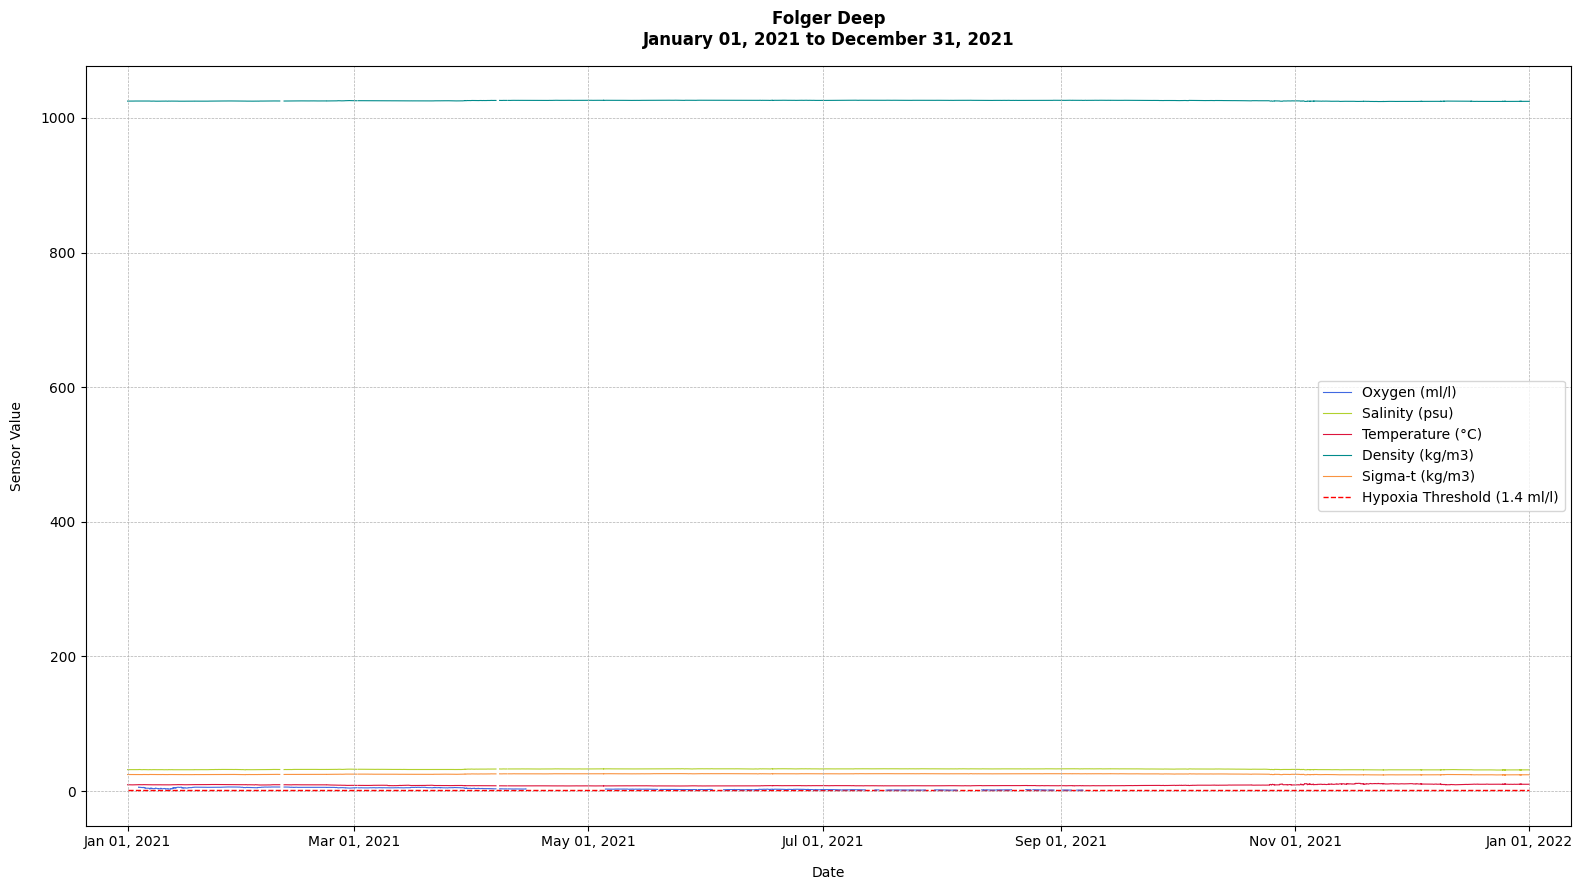

In [26]:
# Refer to onc_plotting.py file to understand plot_dataframe function
# Syntax: onc_plotting.plot.dataframe(df: pandas.DataFrame, location_code: string)
onc_plotting.plot_dataframe(df=deep_yr_21_indicators, location_code=deep_locationCode)

Notice how the absolute scale makes it difficult to view all the parameters together? 

Density is an order of magnitude higher than the others, which obscures any meaningful trends in the data\. Let’s address this by exploring alternative approaches to visualizing the data\.

2\.4\.1\.1 \[Option 1\] Subplot Each Property

One way to look at properties with different magnitudes is to subplot each property with its own y\-axis, while still sharing an x\-axis, in this case date\.

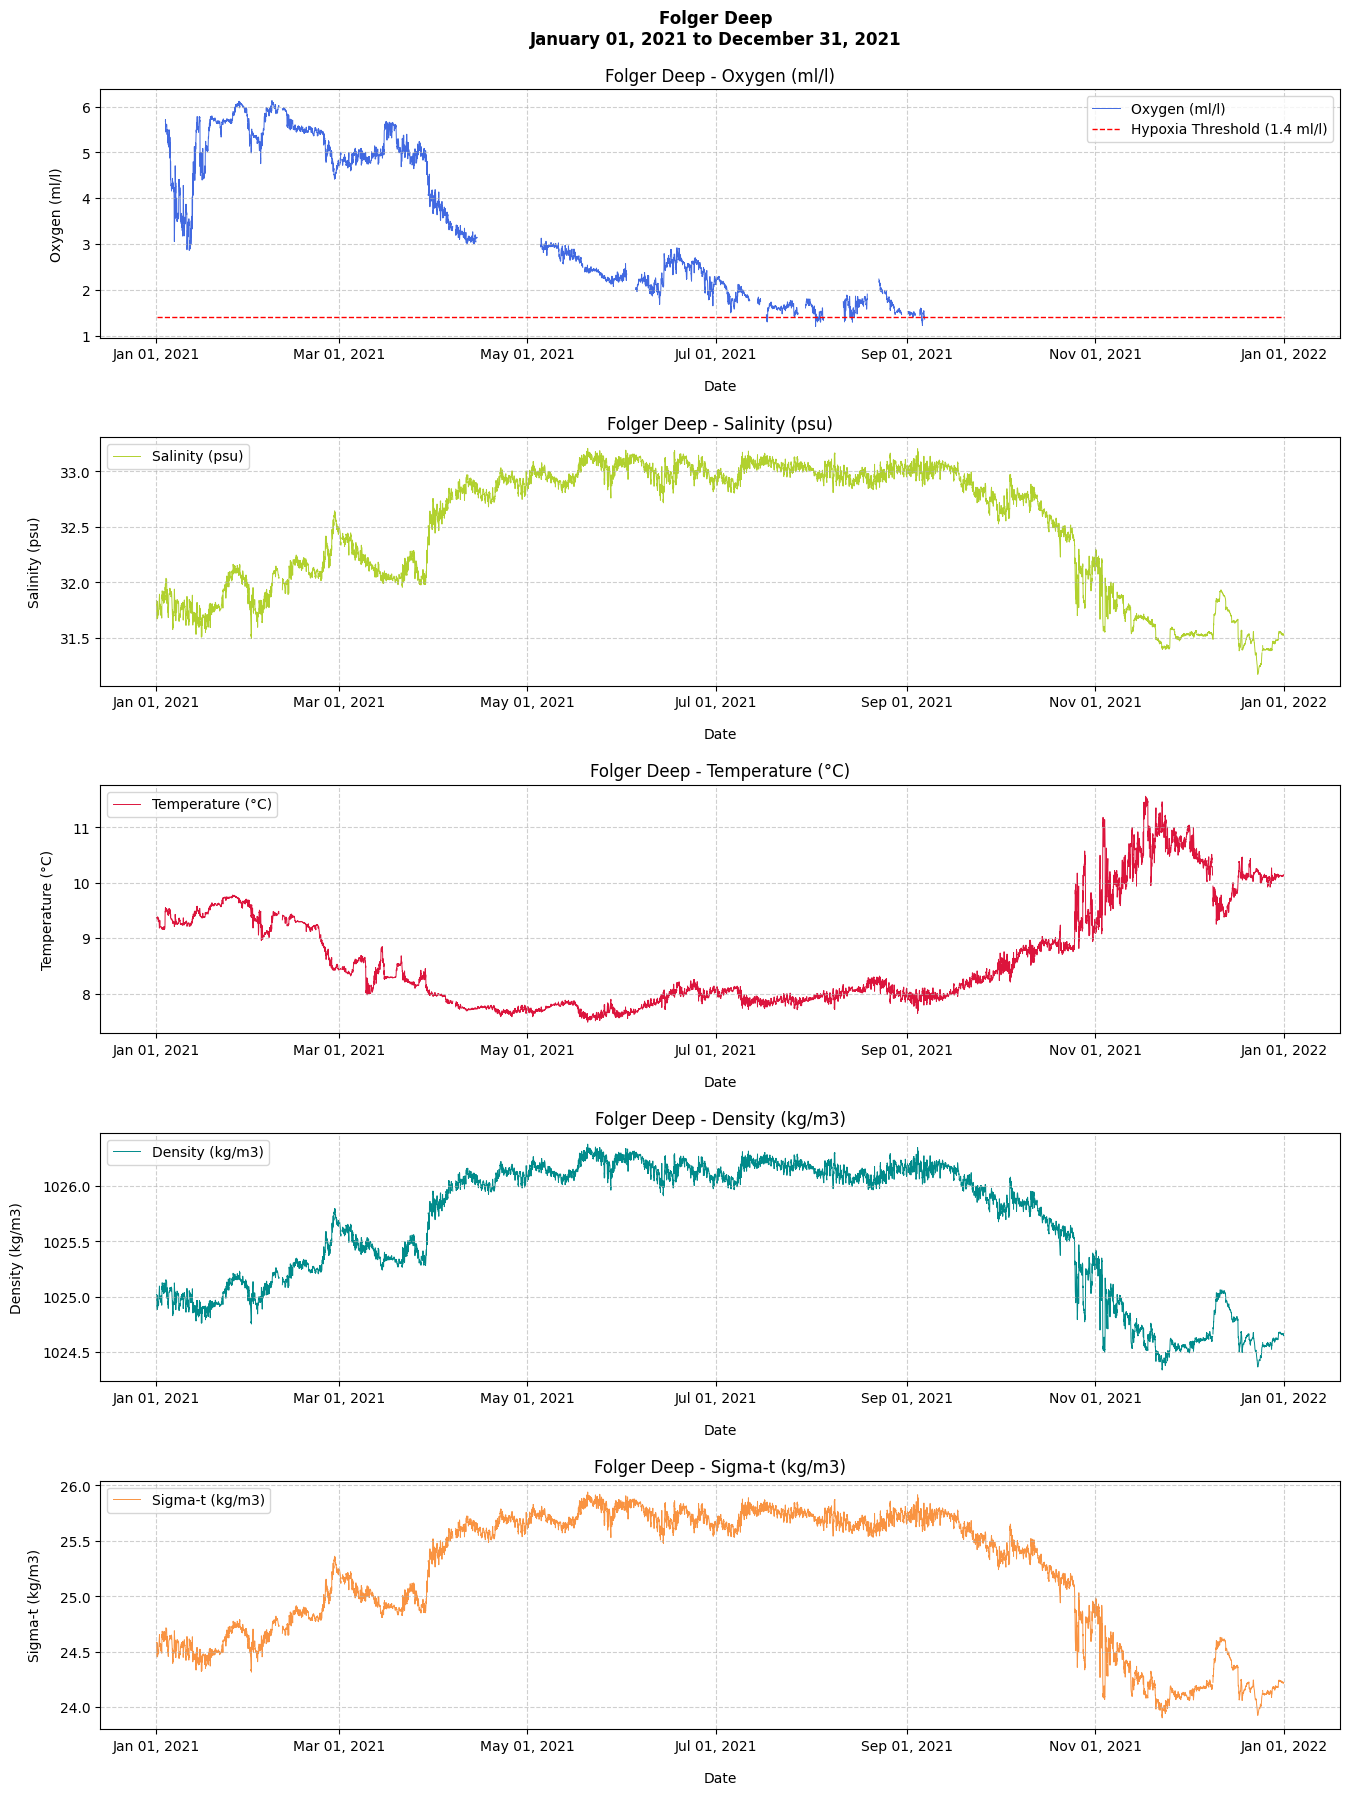

In [27]:
# Refer to onc_plotting.py file to understand subplot_all_with_time function
# Syntax: onc_plotting.subplot_all_with_time(df: pandas.DataFrame, location_code: string)
onc_plotting.subplot_all_with_time(df=deep_yr_21_indicators, location_code=deep_locationCode)

Notice in the oxygen plot above, there is a red dashed line at 1\.4 ml/l\. This indicates a commonly used threshold for low oxygen conditions in a marine environment\. To modify this value, head over to the onc\_plotting\.py file and edit the value for the global variable HYPOXIA\_THRESHOLD on line 14, and then use the Run button in the top right corner of the screen to apply the new value\.

2\.4\.1\.2 \[Option 2\] Use a Twin Y\-Axis for Properties of Different Magnitudes

Another option is to create a twin y\-axis for properties with the largest difference in magnitude\. To do this, we use another of our plotting functions \(plot\_with\_twin\_y\_axis\_for\_outlier\)which places density on its own vertical axis on the right side of the plot, making it easier to compare with other parameters\.

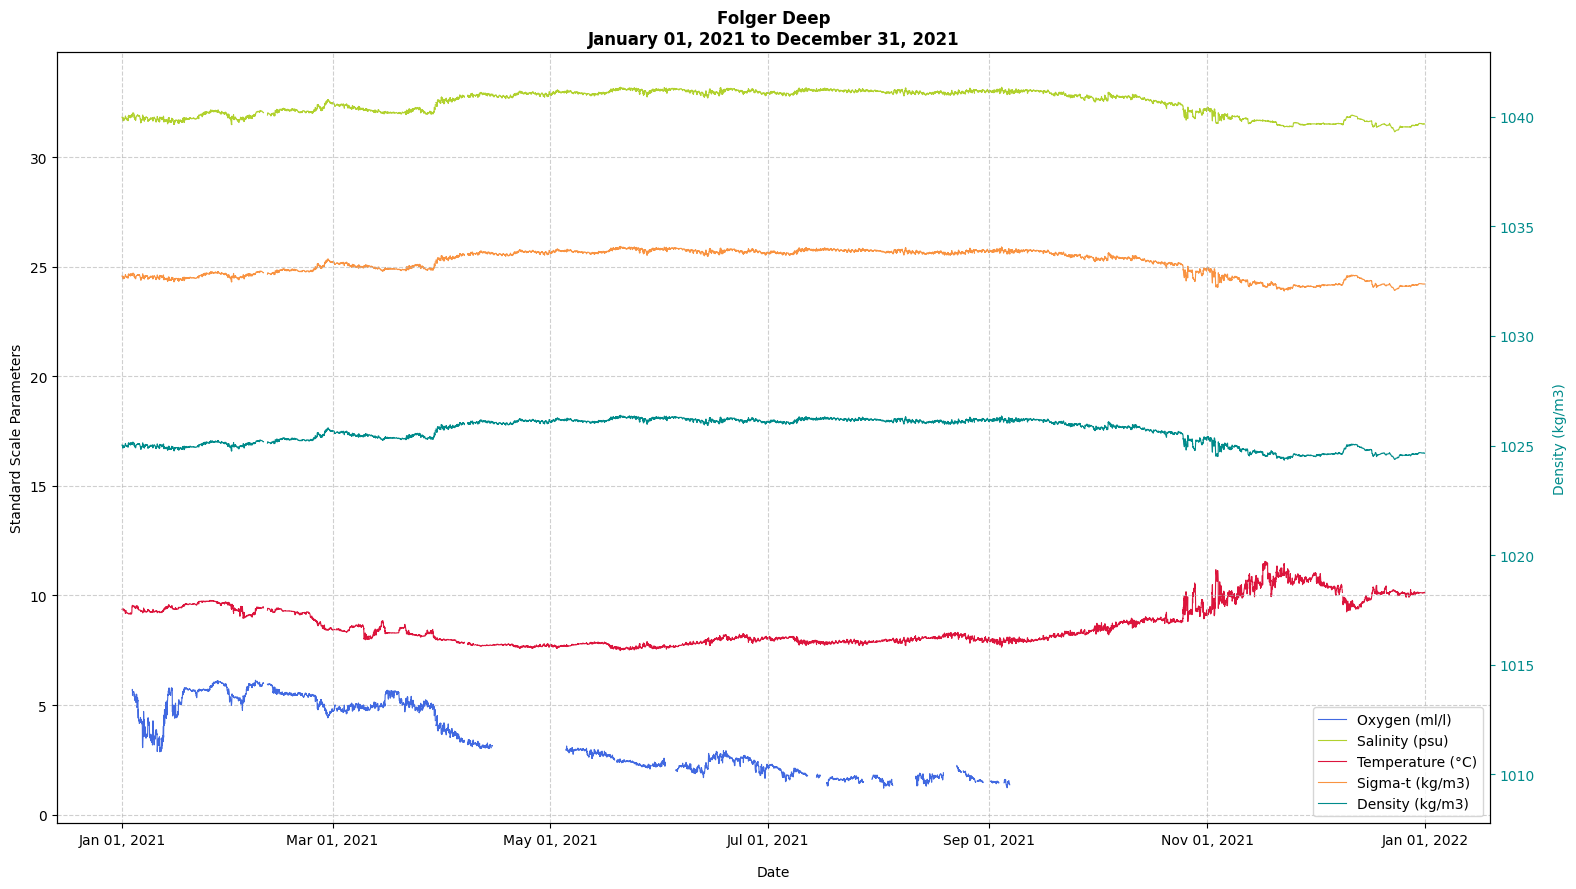

In [28]:
# Refer to onc_plotting.py file to understand plot_with_twin_y_axis_for_outlier function
# Syntax: onc_plotting.plot_with_twin_y_axis_for_outlier(df: pandas.DataFrame, location_code: string)
onc_plotting.plot_with_twin_y_axis_for_outlier(df=deep_yr_21_indicators, location_code=deep_locationCode)

2\.3\.1\.3 \[Option 3\] Apply Oceanographic Knowledge

As you might have noticed, our DataFrame includes both density and sigma t\. These two parameters measure the same data except density takes into account atmospheric pressure while sigma t does not\. That is: sigma t = density \- 1000\. 

Thus, sigma t represents density but at a much lower magnitude, meaning we don't need to plot both\. We'll keep sigma t because it is on the same scale as our other parameters\.

Below we remove the density column from our DataFrame using the pandas drop function, and plot it accordingly\.

In [29]:
# Drop() method removes a column from a DataFrame — see the link above for more information
deep_yr_21_indicators.drop(labels="Density (kg/m3)", axis=1, inplace=True) 

In [30]:
# view the new dataframe
print(deep_yr_21_indicators.columns) # the density column is now gone
deep_yr_21_indicators

Index(['Oxygen (ml/l)', 'Salinity (psu)', 'Temperature (°C)',
       'Sigma-t (kg/m3)'],
      dtype='object')


,Oxygen (ml/l),Salinity (psu),Temperature (°C),Sigma-t (kg/m3)
Time,,,,
2021-01-01 00:15:00+00:00,NaN,31.837662,9.368090,24.585439
2021-01-01 00:45:00+00:00,NaN,31.837139,9.362289,24.585946
2021-01-01 01:15:00+00:00,NaN,31.831736,9.362302,24.581721
2021-01-01 01:45:00+00:00,NaN,31.826527,9.362097,24.577683
2021-01-01 02:15:00+00:00,NaN,31.814458,9.364466,24.567878
...,...,...,...,...
2021-12-31 21:45:00+00:00,NaN,31.523383,10.118536,24.219021
2021-12-31 22:15:00+00:00,NaN,31.522272,10.124838,24.217115
2021-12-31 22:45:00+00:00,NaN,31.522845,10.131310,24.216493


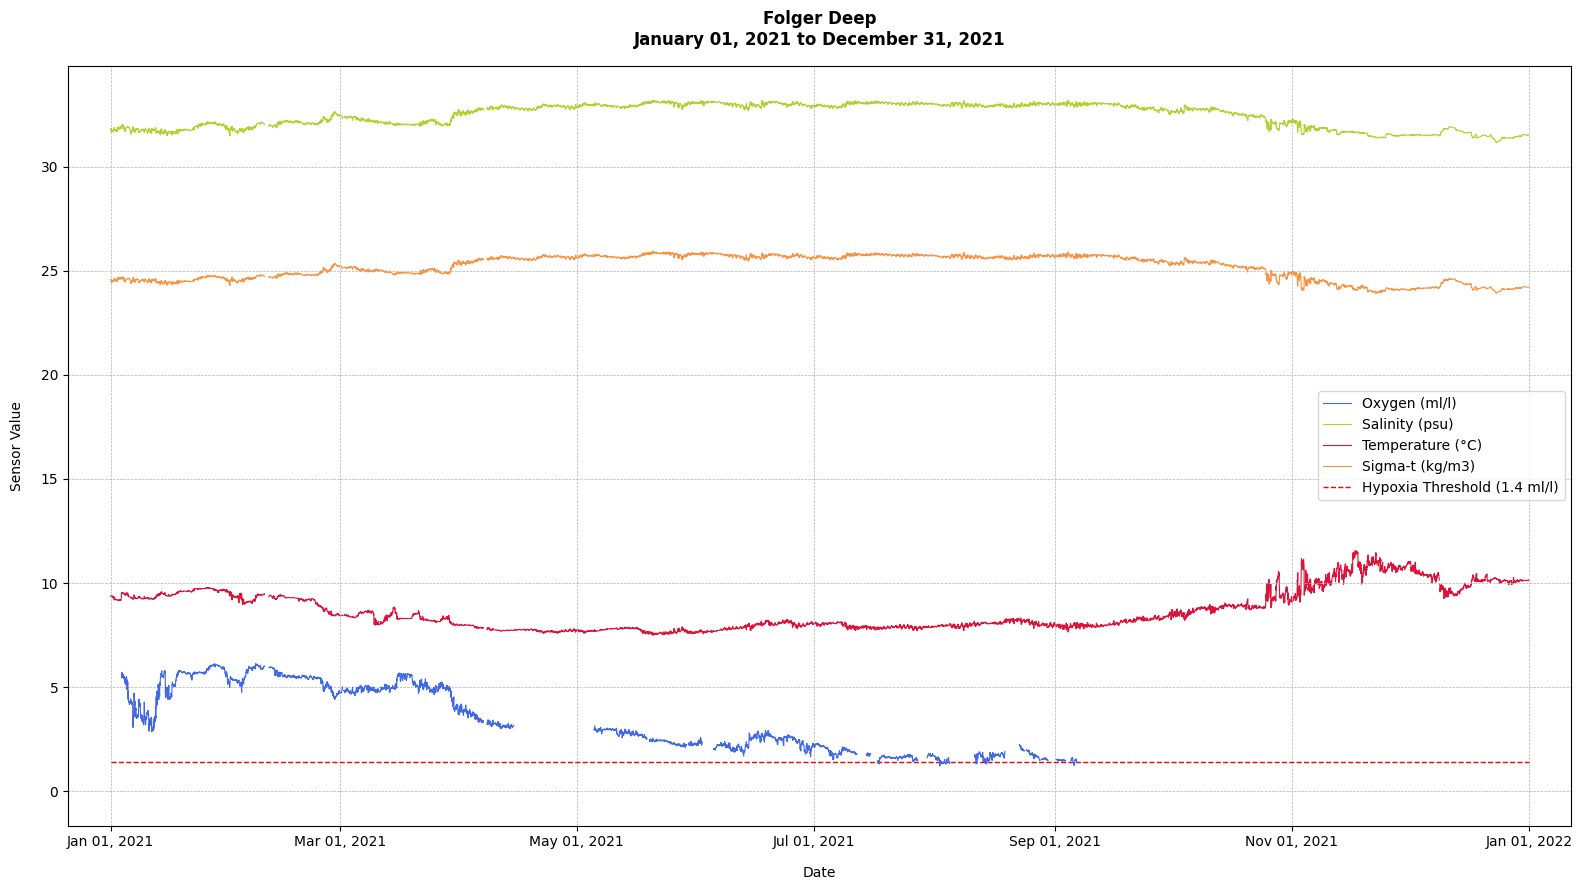

In [31]:
# Refer to onc_plotting.py file to understand plot_dataframe function
# Syntax: onc_plotting.plot_dataframe(df: pandas.DataFrame, location_code: string)
onc_plotting.plot_dataframe(df=deep_yr_21_indicators, location_code=deep_locationCode)

### 2\.4\.2 Folger Pinnacle

Now we'll make the same plots for Folger Pinnacle, but you have to fill in some of the parameters\. Reference the variables defined in section 2\.2 and the functions used to plot Folger Deep above\.

2\.4\.2\.1 \[Option 1\] Subplot Each Property

> Enter the name of the plotting function below\. Refer to our plots of Folger Deep above for reference\.

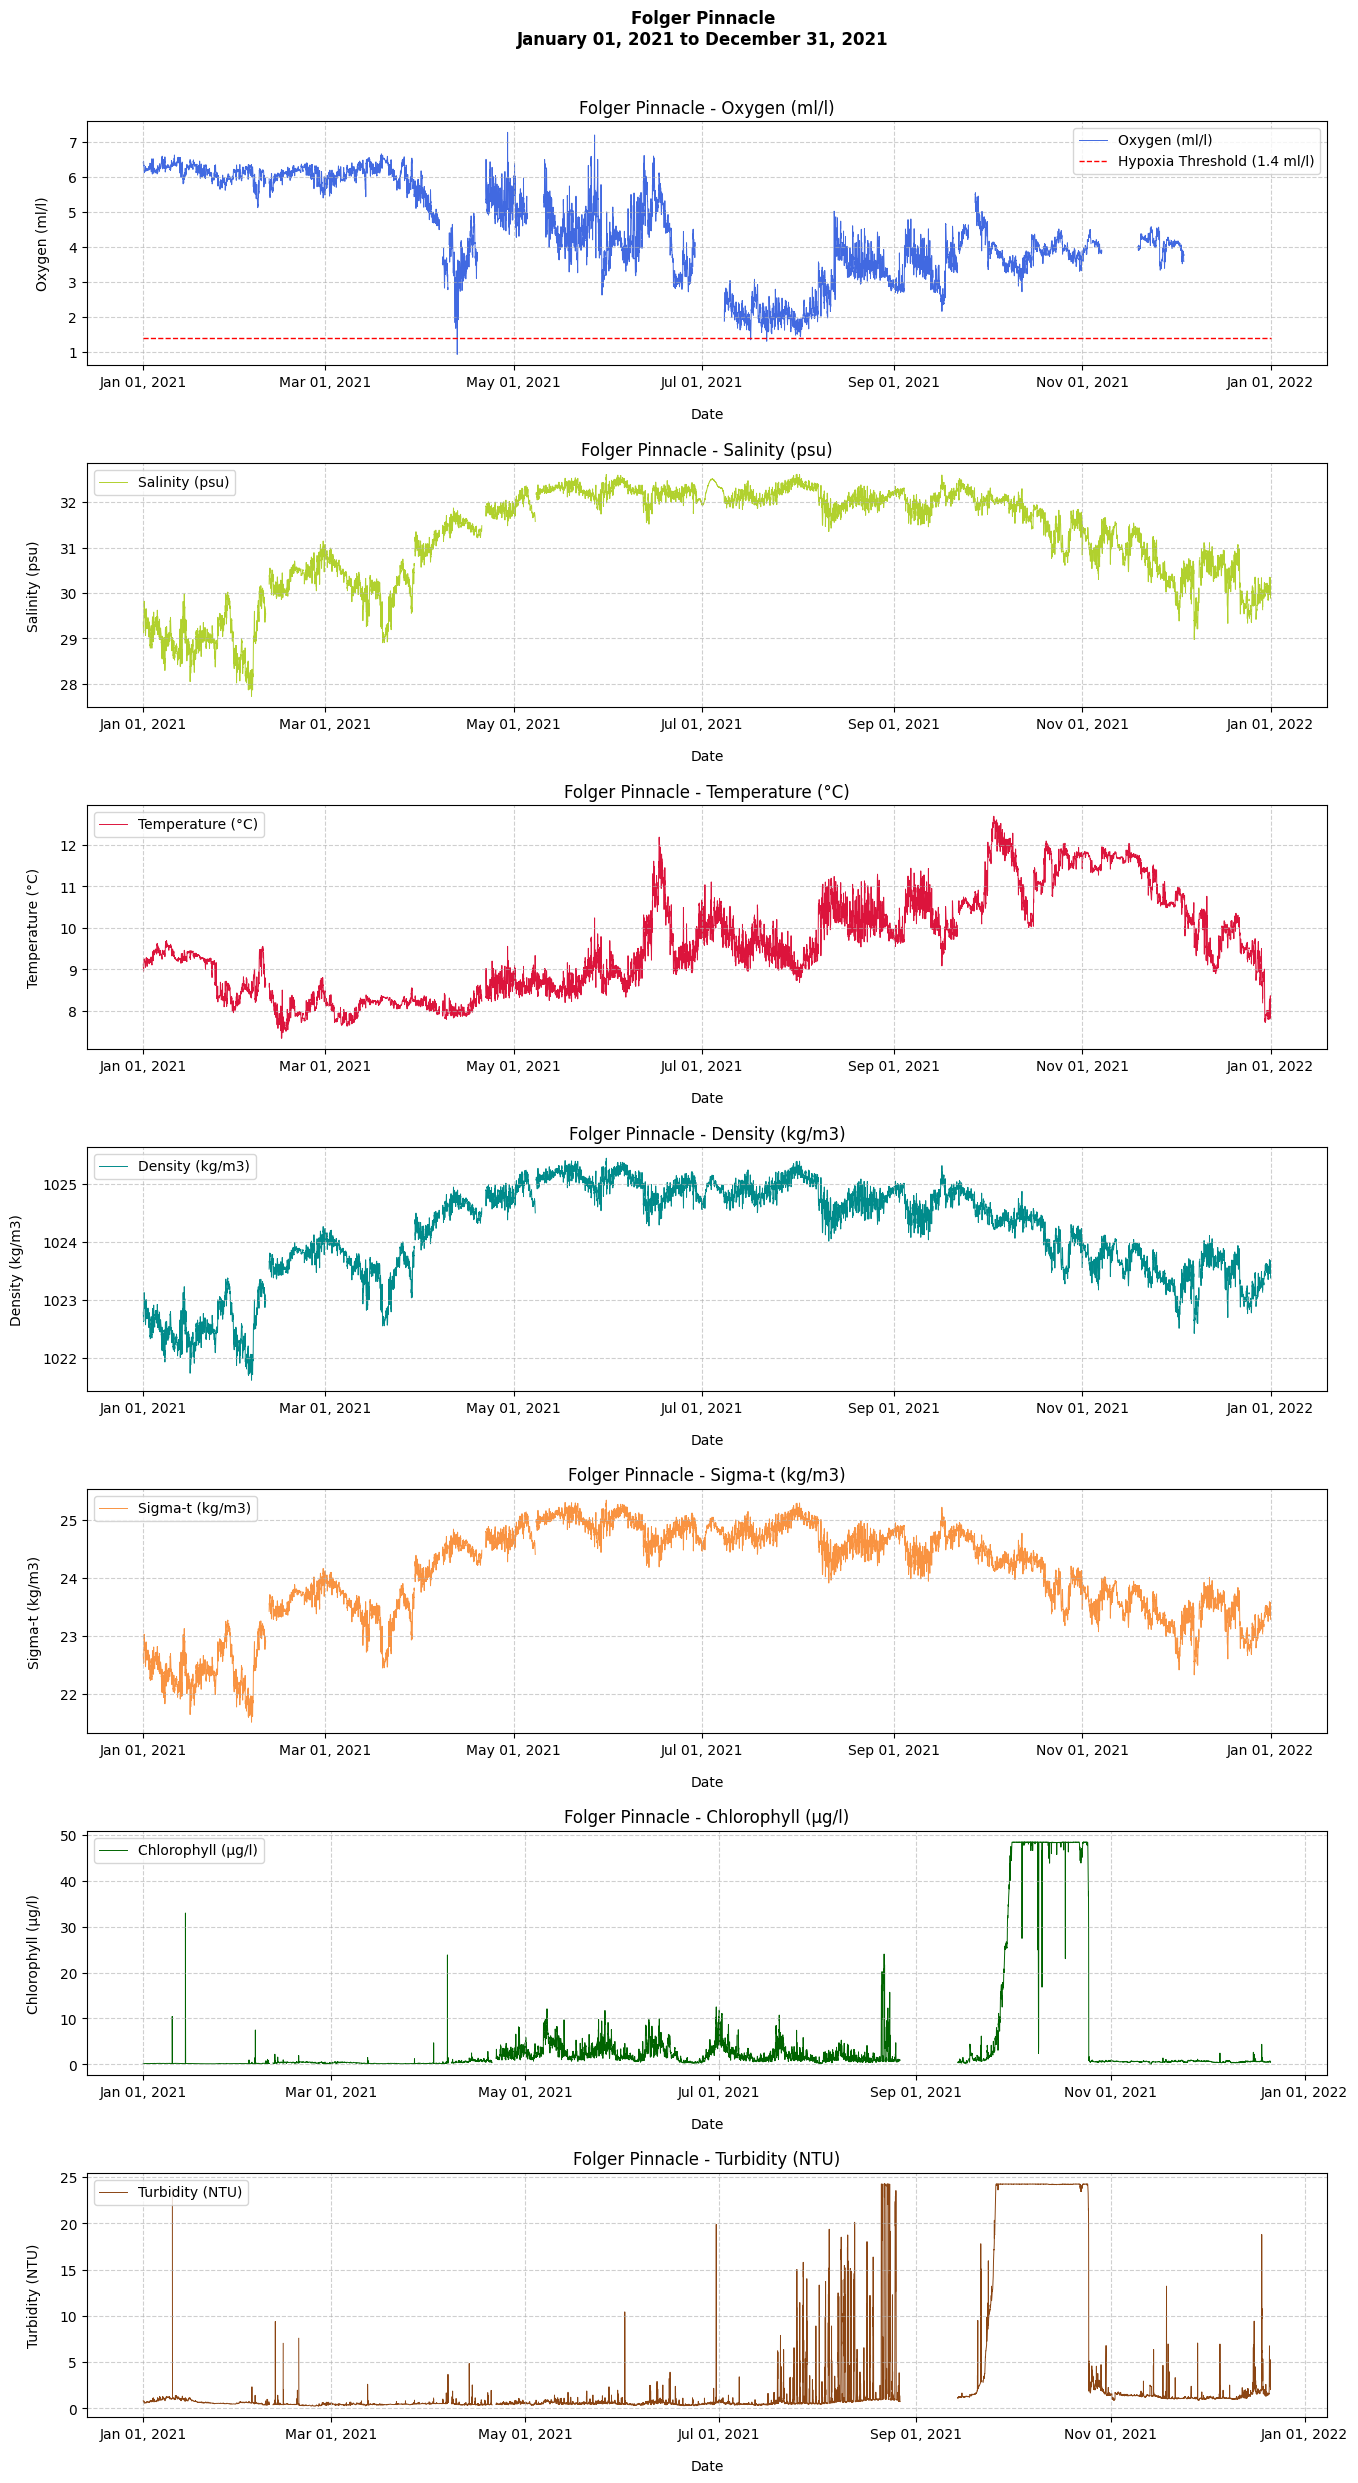

In [32]:
# INTERACTIVE: enter the name of our plotting function
onc_plotting.subplot_all_with_time(df=pin_yr_21_indicators, location_code=pinnacle_locationCode)

Looking at the above graphs, consider the following questions \(click to show the answers\):

<p><details> <summary>Why do you think the chlorophyll started showing up on the sensor in April?</summary><p>In the spring, there was a phytoplankton bloom, caused by the increased light from the sun, and assistend by upwelling, which brought in nutrient-rich water from the deeps. Chlorophyll is a proxy variable for primary production, and increases as the phytoplankton grow.</p></details></p>
<p><details> <summary>Would you expect oxygen to increase or decrease when there is a lot of chlorophyll? Why? </summary> <p>Since cholorphyll is a proxy for primary production, by phytoplankton, increased chlorophyll would likely correspond to an initial oxygen increase, from photosynthesis, followed by a decrease, from respiration.</p></details></p>
<p><details><p><summary>June has an unusual spike in temperature. What do you think caused this?</summary></p> <p><b>Hint:</b> Lytton, BC recorded a new Canadian temperature record of 49.6°C on 29 June, 2021.<details><summary><b>Reveal the answer</b></summary><p>This corresponds to a heatwave event that occured in the Pacific Northwest from ~25 June to ~2 July. This heatwave originated in wind changes across the Pacific acusing alterations to air movement patterns in North America. It had widespread negative impacts, from significantly decreased crop yields to the death of marine life, particularly in the intertidal zone. More information is available in the link below.</p></details></p></details></p>
<p><details><summary>Why do you think the temperature was generally warmer in October - November than it was in May - July?</summary><p>Cold spring meltwater from glaciers on mountains could have cooled the ocean in the early part of the summer.</p></details></p>

> If you're interested in learning more about the June temperature spike, here is an open\-access paper discussing the 2021 heatwave, its causes, and its impacts: https://doi\.org/10\.1038/s41467\-023\-36289\-3

2\.4\.2\.2 \[Option 2\] Use a Twin Y\-Axis for Properties of Different Magnitudes

> Enter the name of the plotting function below\. Refer to our plots of Folger Deep above for reference\.

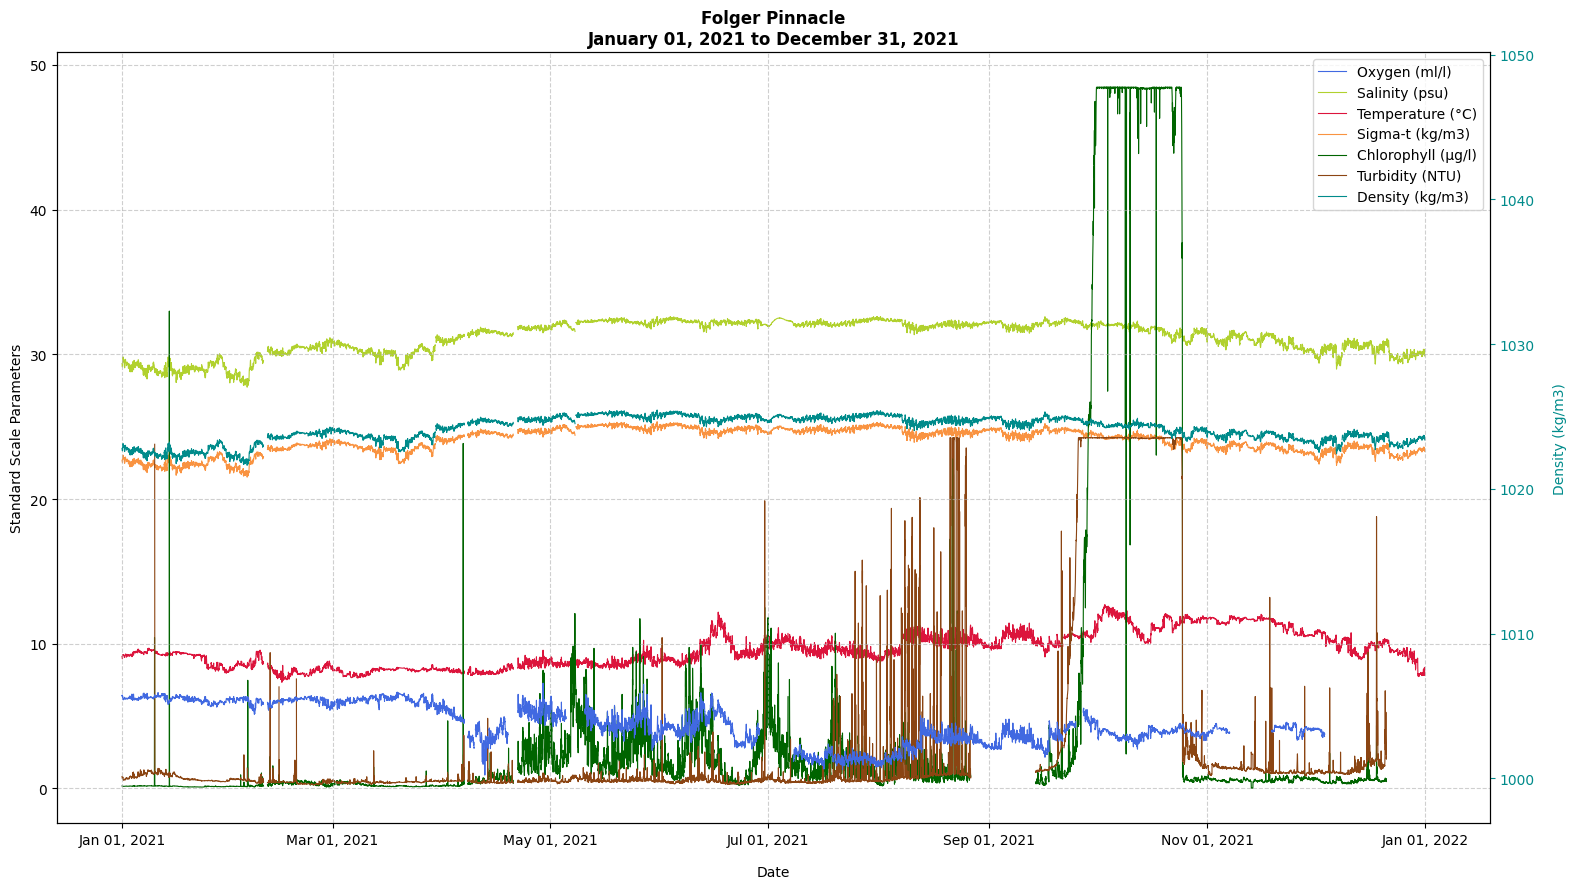

In [33]:
# INTERACTIVE: enter the name of our plotting function
onc_plotting.plot_with_twin_y_axis_for_outlier(df=pin_yr_21_indicators, location_code=pinnacle_locationCode)

2\.3\.2\.3 \[Option 3\] Apply Oceanographic Knowledge

In [34]:
pin_yr_21_indicators.drop("Density (kg/m3)", axis=1, inplace=True) 

In [35]:
# view the new dataframe
print(pin_yr_21_indicators.columns) # the density column is now gone
pin_yr_21_indicators

Index(['Oxygen (ml/l)', 'Salinity (psu)', 'Temperature (°C)',
       'Sigma-t (kg/m3)', 'Chlorophyll (µg/l)', 'Turbidity (NTU)'],
      dtype='object')


,Oxygen (ml/l),Salinity (psu),Temperature (°C),Sigma-t (kg/m3),Chlorophyll (µg/l),Turbidity (NTU)
Time,,,,,,
2021-01-01 00:15:00+00:00,6.418278,29.356030,9.125013,22.683785,0.173206,0.823635
2021-01-01 00:45:00+00:00,6.417333,29.282496,9.079078,22.633191,0.168771,0.782812
2021-01-01 01:15:00+00:00,6.372171,29.251519,9.025827,22.616893,0.159257,0.707104
2021-01-01 01:45:00+00:00,6.365439,29.233654,9.021572,22.603566,0.156167,0.690834
2021-01-01 02:15:00+00:00,6.452396,29.164227,8.973576,22.556397,0.155061,0.669201
...,...,...,...,...,...,...
2021-12-31 21:45:00+00:00,NaN,30.222132,8.280649,23.484530,NaN,NaN
2021-12-31 22:15:00+00:00,NaN,30.254641,8.367470,23.497613,NaN,NaN
2021-12-31 22:45:00+00:00,NaN,30.225979,8.230905,23.494489,NaN,NaN


> Enter the name of the plotting function below\. Refer to our plots of Folger Deep above for reference\.

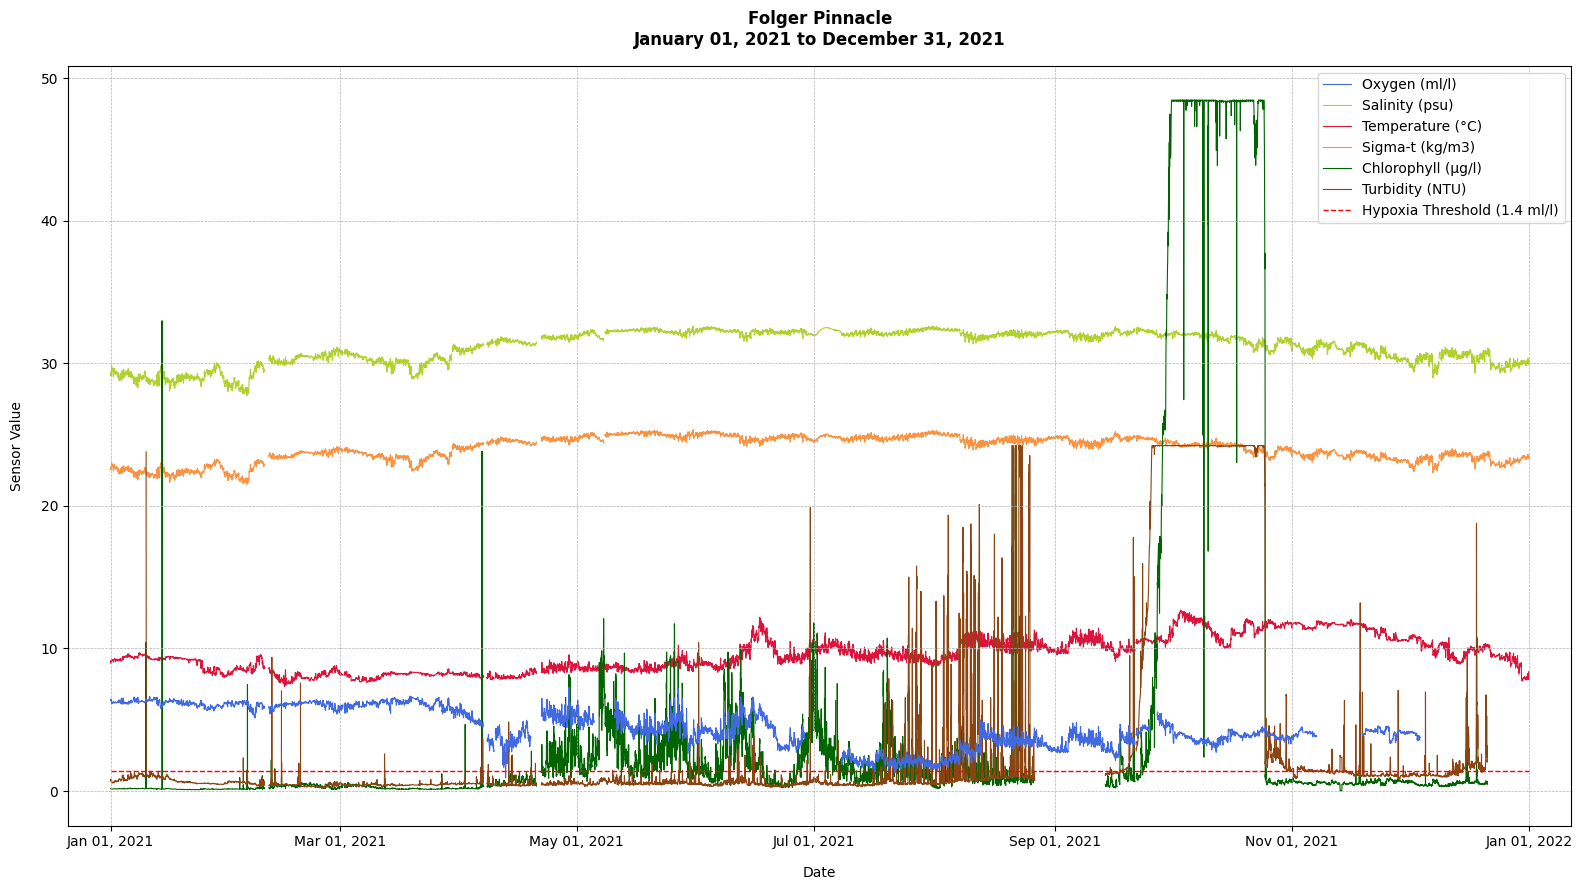

In [36]:
# INTERACTIVE: enter the name of our plotting function
onc_plotting.plot_dataframe(df=pin_yr_21_indicators, location_code=pinnacle_locationCode)

### 2\.5 Comparing Folger Deep and Folger Pinnacle

We can also compare properties at different depths by subplotting and overlaying each property at Folger Deep and Folger Pinnacle\.

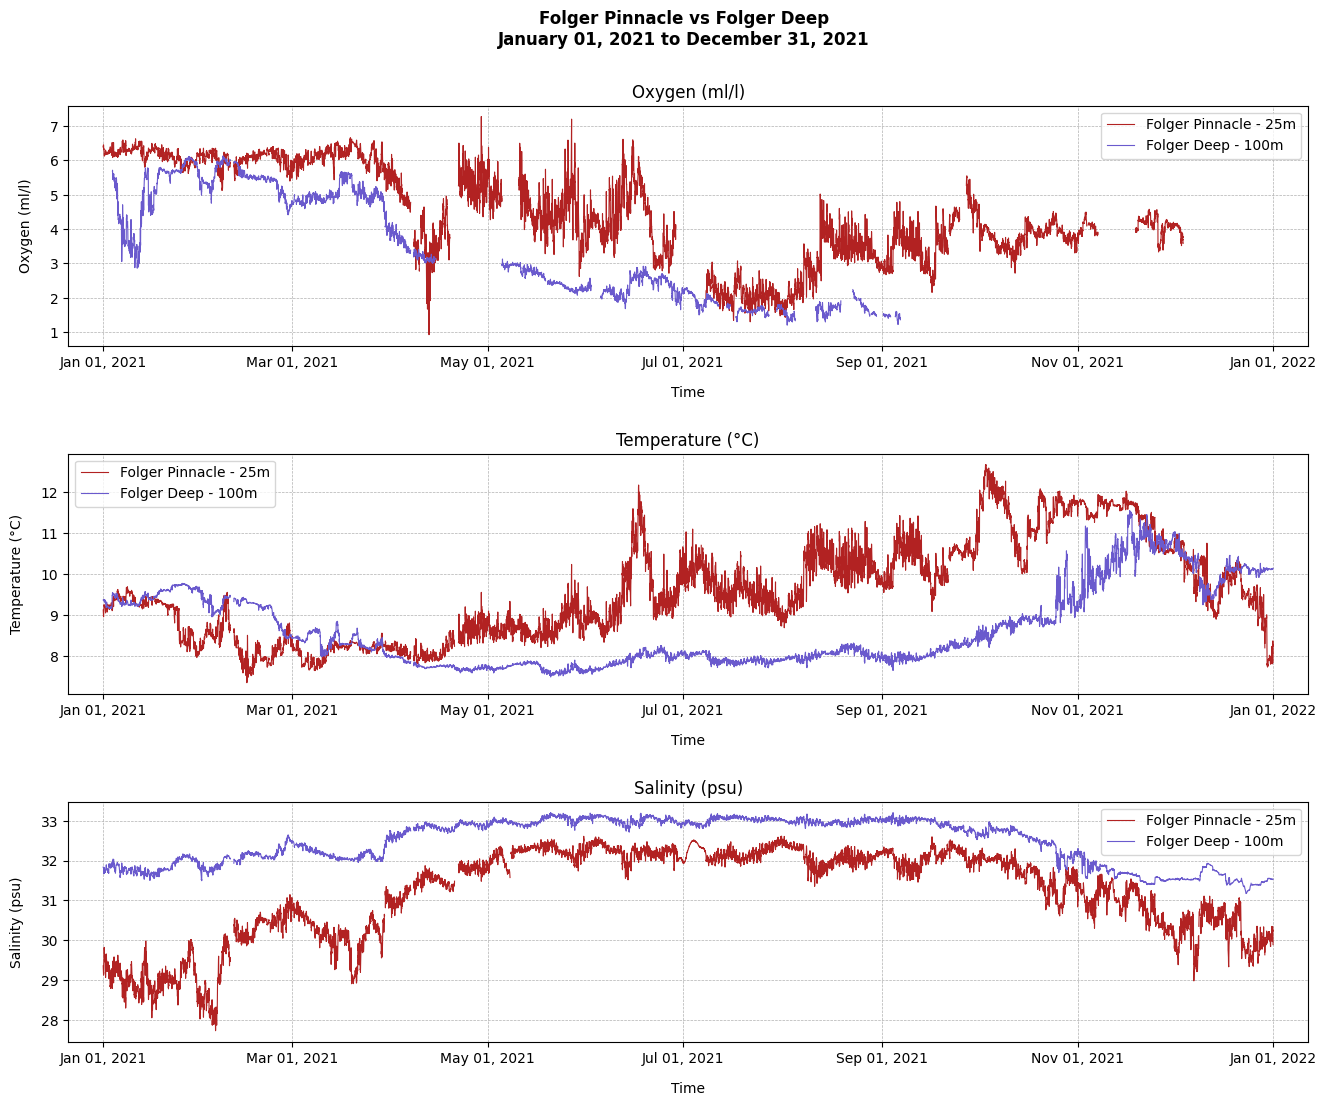

In [37]:
onc_plotting.compare_sensor_subplots(df1=deep_yr_21_indicators, df2=pin_yr_21_indicators, sensor_cols=["Oxygen (ml/l)", "Temperature (°C)", "Salinity (psu)"], location_code1=deep_locationCode, location_code2=pinnacle_locationCode)

Looking at the above plots, consider the following questions\. Click to reveal the answers:

<details><summary>Why are oxygen values generally higher at Pinnacle than Deep, and what could cause them to be similar in late summer?</summary><p>The increased levels of oxygen at Folger Pinnacle are primarily due to photosynthesis by phytoplankton, a process which is limited to the upper layers of the water column due to its reliance on sunlight. The similarity later in the summer is likely due to respiration from the decay of the phytoplankton bloom, which would have decreased the oxygen in the surface layers. While physical mixing of the surface water with air could also play a role in raising oxygen, we can tell that upwelling and downwelling are not major factors because salinity values between the depths remain distinct.</p></details>
<details><summary>Why were Folger Deep temperatures warmer than Folger Pinnacle temperatures during mid January - mid March?</summary><p>The warmer temperatures in the deep water during the winter months are due to the fact that air warms and cools more quickly than water, so the deep water is insuated from seasonal extremes in temperature. While upwelling and downwelling can play a role in this effect, in this case the distinct salinity values indicate that there was little exchage between the deep and shallow water masses.</p></details>
<details><summary>Why was salinity consistently higher at Folger Deep than Folger Pinnacle?</summary><p>Saltwater is heavier than freshwater, so it sinks. This means that salinity usually increases with depth.</p></details>
<details><summary>What could have caused temperature to be nearly the same between the locations in December?</summary><p>During the fall storm season, increased mixing between the surface and the deep likely caused more similar salinity levels. Downwelling, in which surface waters sink deeper likely also plays a role.</p></details>

## 3\. Plotting Shorter Time Series

Now say we'd like to inspect a specific time period within the year of 2021\. Instead of repeating API calls, which are time and resource intensive, we can use the full\-year DataFrames we have already generated, and extract smaller time periods of interest from them\. 

### 3\.1 Define Time Periods of Interest

From looking at the year long plots above we can identify several time periods that would prompt further investigation including a potential low oxygen event from July to September\.

In the code below we define the start and end dates of the new time period as strings\. 

In [38]:
# July - September
jul_01_str = "2021-07-01T00:00:00.000Z"
sep_01_str = "2021-09-01T00:00:00.000Z"

### 3\.2 Convert Dates to 'Timestamp' Objects

After defining our dates as strings, we then convert them to pandas Timestamp objects using the pandas to\_datetime function\. Doing this is necessary for the next step: it tells the program that these variables represent moments in time, rather than just text\.

In [39]:
# July - September
jul_01 = pandas.to_datetime(jul_01_str)
sep_01 = pandas.to_datetime(sep_01_str)

### 3\.3 Create New DataFrames by 'Slicing' the Original

Now that the timestamps are defined, we use them to 'slice' specific time\-based subsets of the full DataFrame\. This is done using the pandas DataFrame\.loc function, which selects only the rows from the DataFrame that fall between given start and stop dates\.

#### 3.3.1 Slicing Example

Below, is an example of an initial DataFrame, with the red box outlining the start and end times where we slice it, according to the following code:

             deep\_yr\_21\_indicators\.loc\["2021\-01\-01T04:00:00\.000Z":"2021\-01\-01T08:00:00\.000Z"\]

<img src="(3) Folger Passage 2021 files/original_dataframe.png" width="" align="" />

We then see the new DataFrame this command produces\.

<img src="(3) Folger Passage 2021 files/new_dataframe.png" width="" align="" />

#### 3.3.2 Apply Slicing

Following this same technique, we can isolate our period of interest at both Folger Deep and Folger Pinnacle\. 

In [40]:
# Folger Deep: Slice views of the full-year data
deep_low_ox_df = deep_yr_21_indicators.loc[jul_01:sep_01]          # Potential low oxygen

In [41]:
# Folger Pinnacle: Slice views of the full-year data
pin_low_ox_df = pin_yr_21_indicators.loc[jul_01:sep_01]            # Potential low oxygen

Let's investigate our new DataFrame\. We're going to print out its shape to get a sense of how long it is compared to the original\.

In [42]:
# compare the number of rows in the sliced DataFrame to the original
print(deep_yr_21_indicators.shape) # number of rows and columns of the original
print(deep_low_ox_df.shape) # number of rows and columns of the new dataframe

# CHALLENGE: check the length of the new pinnacle DataFrame as well!
print(pin_low_ox_df.shape) # number of rows and columns of the new dataframe

(17520, 4)
(2976, 4)
(2976, 6)


<details><summary>Do these numbers make sense for the lengths of our new DataFrames?<p> <b>Click to reveal the answer.</b></p></summary> <p>We originally requested 5 columns for the Deep dataset, but since we dropped one, 4 is expected. The sliced Deep dataset has 2976 rows, which is equal to (31 + 31) days * 24 hours a day * 2 data points an hour, also exactly what we expected.</p></details>

### 3\.4 Create Visualizations Using the DataFrames

And now that we have DataFrames with our specific period, we can plot them just like we would our original DataFrame\. 

#### 3.4.1 Potential Low Oxygen Event at Folger Deep

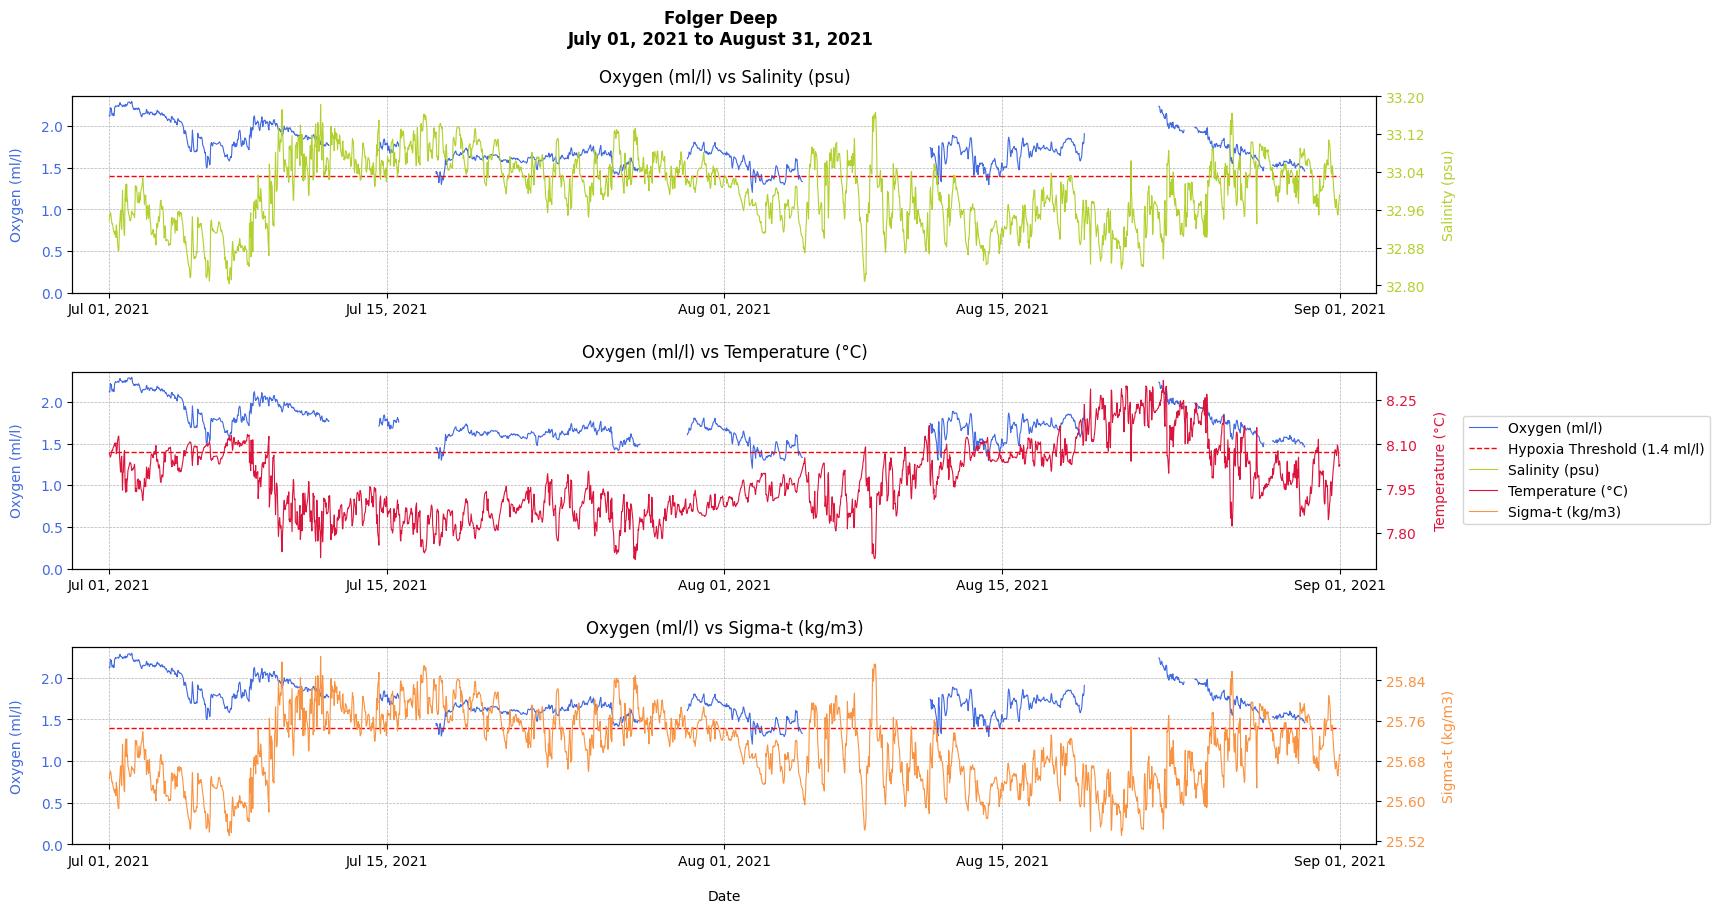

In [43]:
onc_plotting.subplot_all_with_oxygen(df=deep_low_ox_df, location_code=deep_locationCode)

#### 3.4.2 Potential Low Oxygen Event at Folger Pinnacle

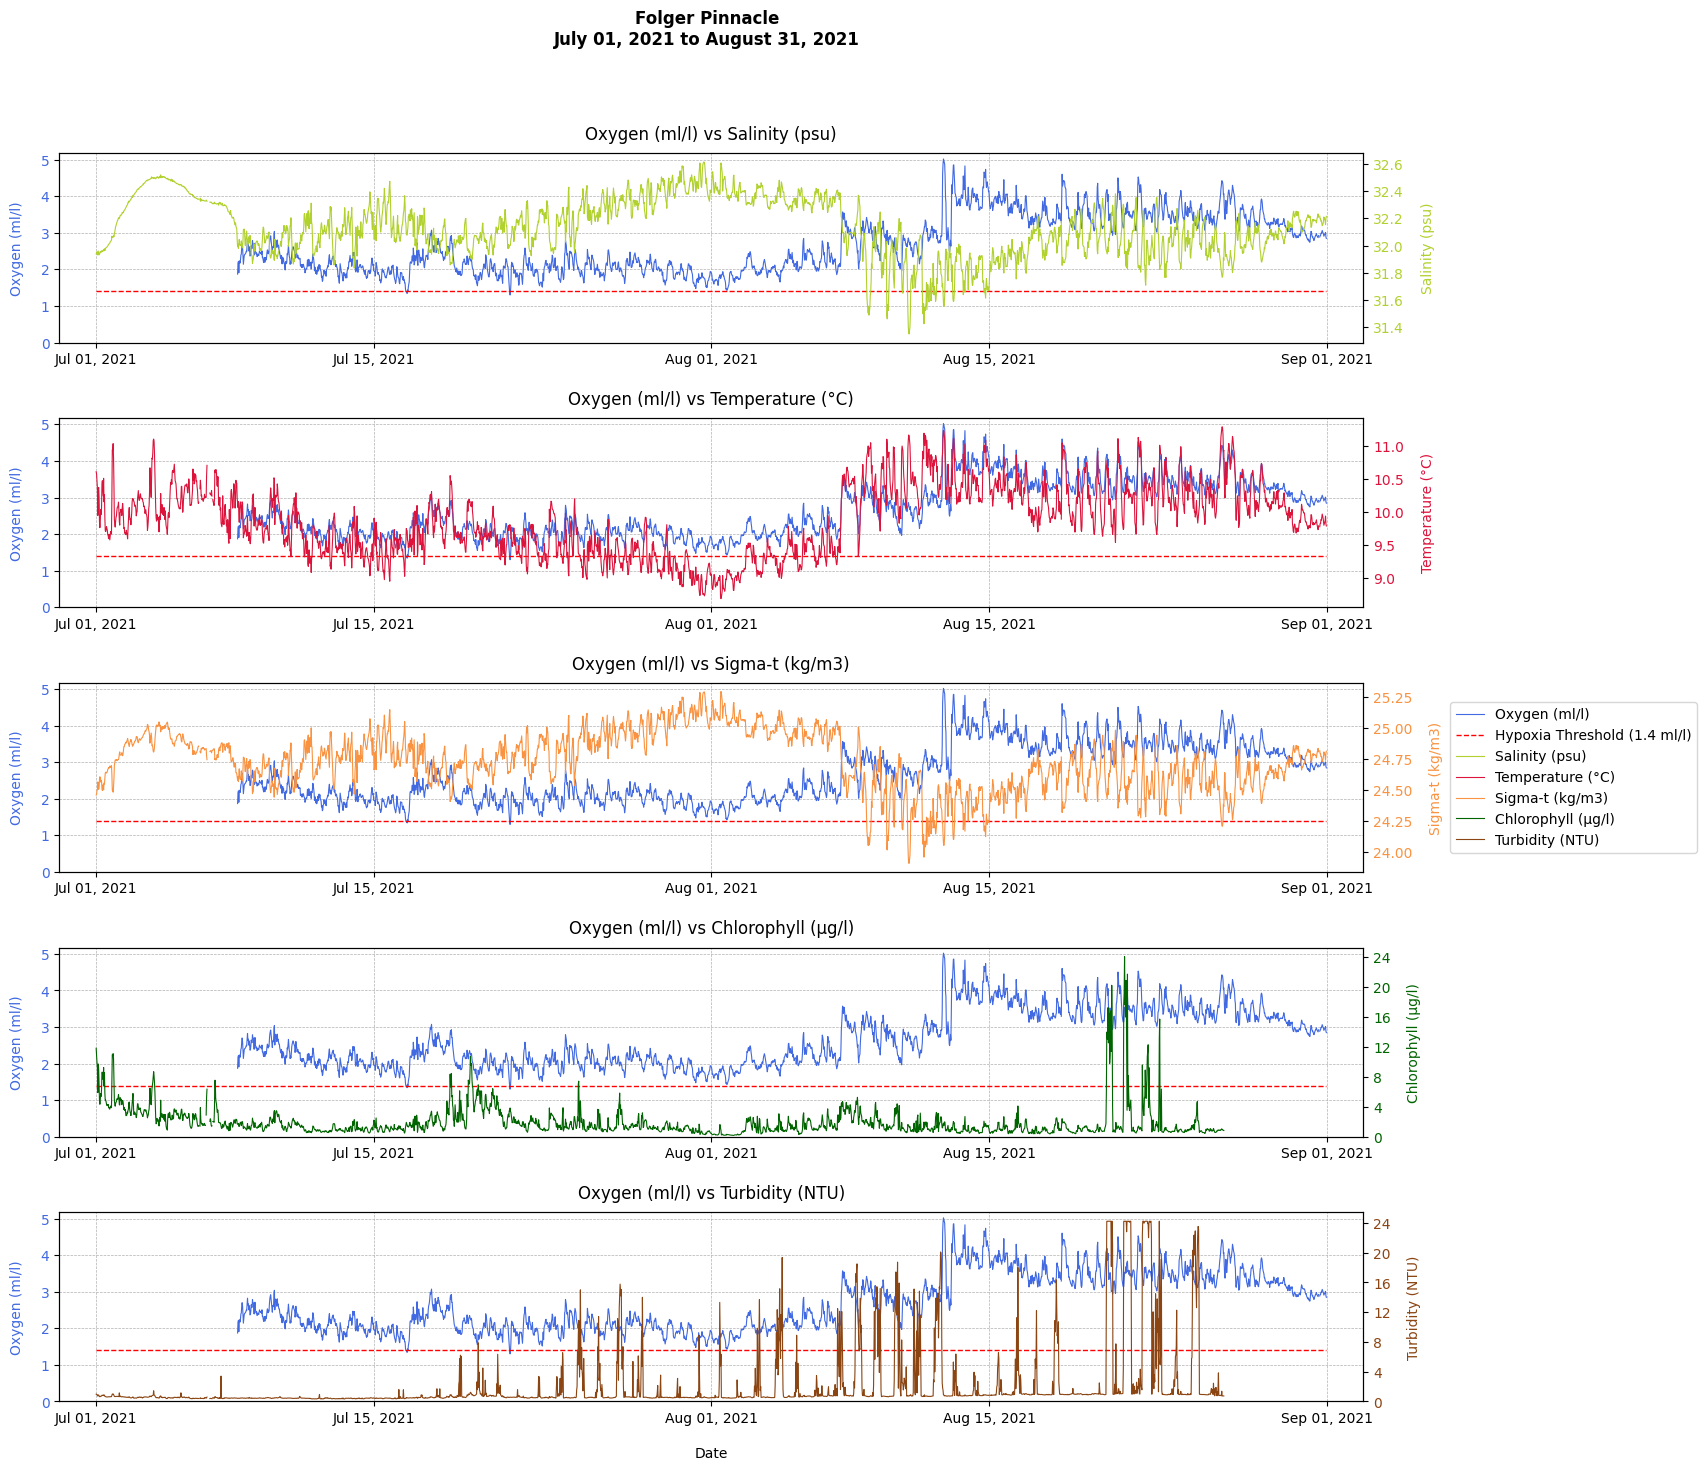

In [44]:
onc_plotting.subplot_all_with_oxygen(df=pin_low_ox_df, location_code=pinnacle_locationCode)

### 3\.5 Interpret the Graphs

Looking at the above graphs, consider the following questions\. Click to show the answers:

<details><summary>How would you describe the relationship between salinity and oxygen? Why do we see a reversal in these properties over the course of the plot?</summary><p>Generally, oxygen and salinity are inversely related. During the first part of the graph, there was upwelling, bringing cold salty, low-oxygen water to the surafce. But as the upwelling decreases, the water becomes less salty and more oxygenated.</p></details>

<details><summary>Which parameter aligns most closely with oxygen? Why do you think they are closely aligned?</summary><p>At the surface, temperature and oxygen are closely correlated, because sunlight both provides energy for oxygen production by photosynthesis, and warms the water.</p></details>

<details><summary>Do you see any obvious correlations between chlorophyll and turbidity?</summary><p>Chlorophyll and turbidity are closely correlated because turbidity is a measure of the amount of suspended particles in the water, and chlorophyll is included in that measure. Non-chlorphyll turbidity is largely sediment, which can come from a wide diversity of sources, including animals, humans, rivers, and even volcanic eruptions.</p></details>

## 4\. Potential High Chlorophyll Event

Looking at our year long plots we can also see another potential event of interest — high chlorophyll from mid September to November\.

Following the same steps as in section 3 we can create a new DataFrame for this period\.

### 4\.1 Define Time Periods of Interest

In [45]:
# Mid September - November
sept_15_str = "2021-09-15T00:00:00.000Z"
nov_01_str = "2021-11-01T00:00:00.000Z"

### 4\.2 Convert Dates to 'Timestamp' Objects

In [46]:
# Mid September - November
sept_15 = pandas.to_datetime(sept_15_str)
nov_01 = pandas.to_datetime(nov_01_str)

### 4\.3 Create New DataFrames by 'Slicing' the Original

In [47]:
# Folger Pinnacle: Slice views of the full-year data
# INTERACTIVE: perform the slicing operation, as we did above
# using the variables for the high chlorophyll event
pin_high_chlor_df = pin_yr_21_indicators.loc[sept_15:nov_01]       # Potential high chlorophyll

### 4\.4 Investigate new DataFrame

In [48]:
# compare the number of rows in the sliced DataFrame to the original
print(pin_yr_21_indicators.shape) # number of rows and columns of the original
print(pin_high_chlor_df.shape) # number of rows and columns of the new dataframe

(17464, 6)
(2256, 6)


### 4\.5 Create Visualizations Using the DataFrame

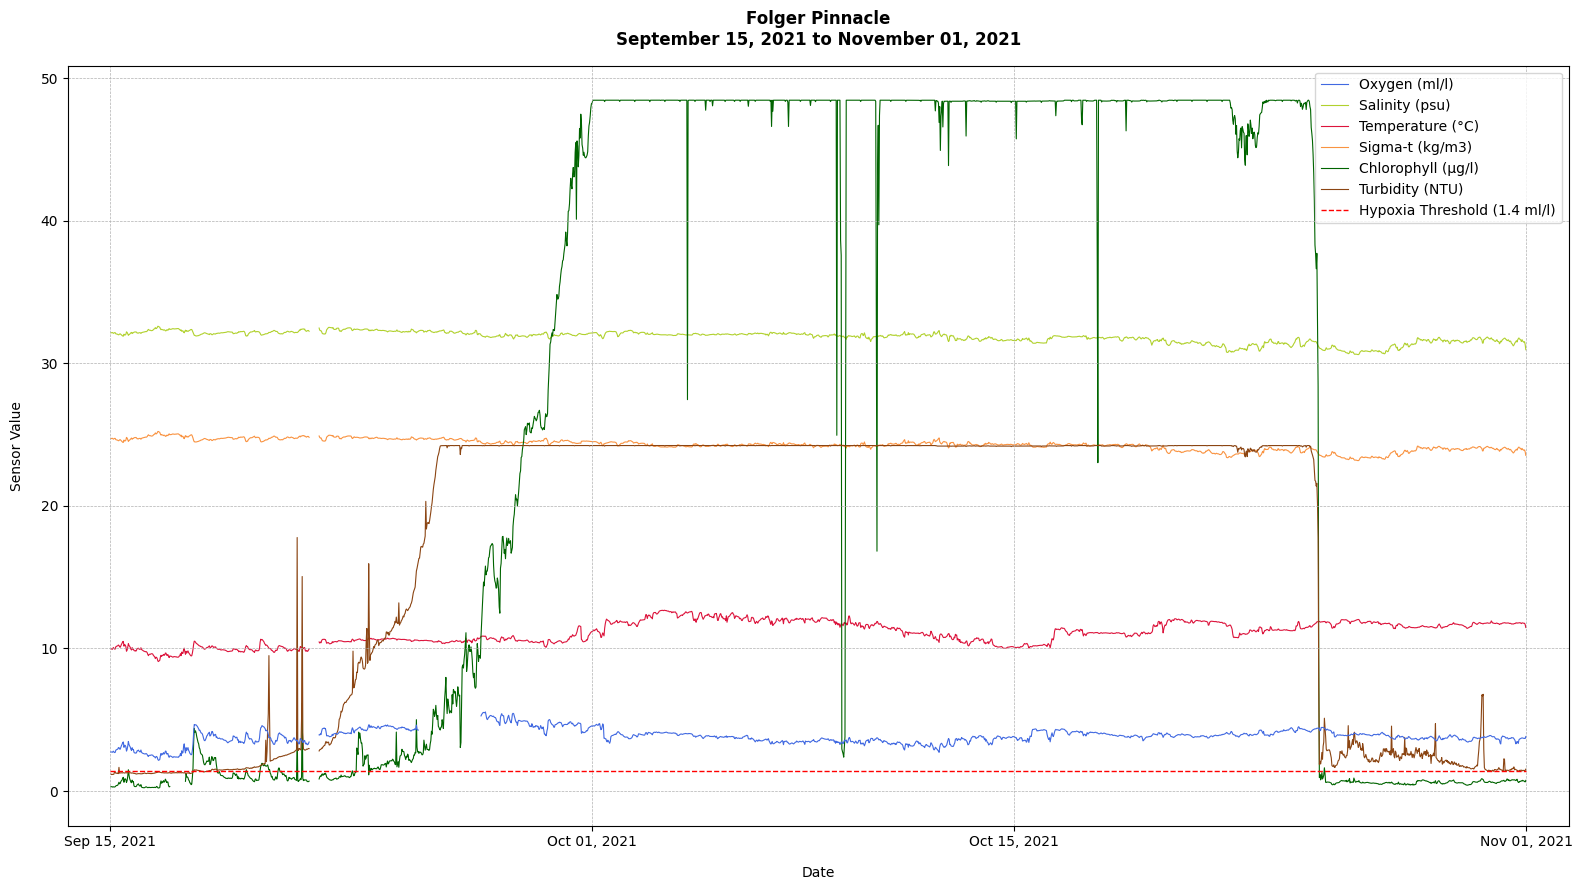

In [49]:
onc_plotting.plot_dataframe(df=pin_high_chlor_df, location_code=pinnacle_locationCode, start=sept_15, end=nov_01)

### 4\.6 Interpret the Graph

<details><summary>Why did both the chlorophyll and turbidity curves go flat after reaching a high value? What could have caused the chlorophyll and turbidity to reach such high values at this time of year? Does it make sense for a phytoplankton bloom to happen in this area during late September and October?<p> <b>Click to reveal the answer.</b></p></summary> <p>The curves plateaued at a high value because the sensors reached their maximum value. This occured in October, which is not a normal time for a phytoplankton bloom (we would expect spring or summer). In fact, this sustained high value suggests that biofouling occured. Organisms accumulated on the surface of the sensors, causing them to read extremely high chlorophyll and turbidity values. This is a common problem for ONC sensors in shallow water. In fact, there are currently UV anti-biofouling devices attached to the Folger Pinnacle observatory to deal with this exact problem!</p></details>

The following photos show the Folger Pinnacle 3D camera array before deployment in 2010 \(left\) and after a year in the water \(right\)\. This might give you a better idea of what occurred on the sensors in fall 2021\.

<img src="(3) Folger Passage 2021 files/folger_camera_array_2010_2011.png" width="" align="" />

Variations in CTD and oxygen records for Folger Deep \(100m\) have strong linkages with the regional upwelling and downwelling signals\. The cold, salty upwelling season in 2021 started on 21 March, over a full month ahead of the climatological mean of April 26\. This upwelling was sustained for over 6 months\. Low oxygen conditions were observed as early as April in 2021\. “Low dissolved oxygen levels have become the norm in the Pacific Northwest coast, but this event started much earlier than we’ve seen in our records,” said Oregon State University Professor Francis Chan, director of the NOAA cooperative institute CIMERS\. “This is the earliest start to the upwelling season in 35 years\.” Typically, hypoxic conditions don’t appear until  late June or early July, he said\. \[Source article\] Recall that we saw the upwelling strength diminish in the graphs earlier, in August, six months after the onset in March\.

# 5 Challenges

## 5\.1 Challenge: Investigate the June Heat Wave

In June 2021 there was a major heat wave that affected ecosystems across the Pacific Northwest\. "Near\-surface air temperature anomalies reached up to 16–20 °C above normal over a wide region, with many locations breaking all\-time maximum temperature records by more than 5 °C\. The Canadian national temperature record was broken 3 days in a row, at multiple locations, with the highest temperature of 49\.6 °C recorded in Lytton, BC, on 29 June, 4\.6 °C higher than the Canadian record prior to this event\." \(White et al, 2023\)

<img src="image-20260731-091052.png" width="75" align="" />

Heat wave daily maximum near\-surface temperatures\. Top: Temperature anomalies relative to a daily 1981–2020 climatology\. Bottom: Temperature values for 2021 compared to 1981 to 2020 climatology\. Figure from https://doi\.org/10\.1038/s41467\-023\-36289\-3

The heat wave lasted approximately from June 25 to July 2\. Try investigating the impact of the heat wave on conditions at Folger Deep and Pinnacle by following the method used above to examine the low oxygen and high chlorophyll event\. Which location shows a stronger temperature response? Which other variables did the heat wave impact?

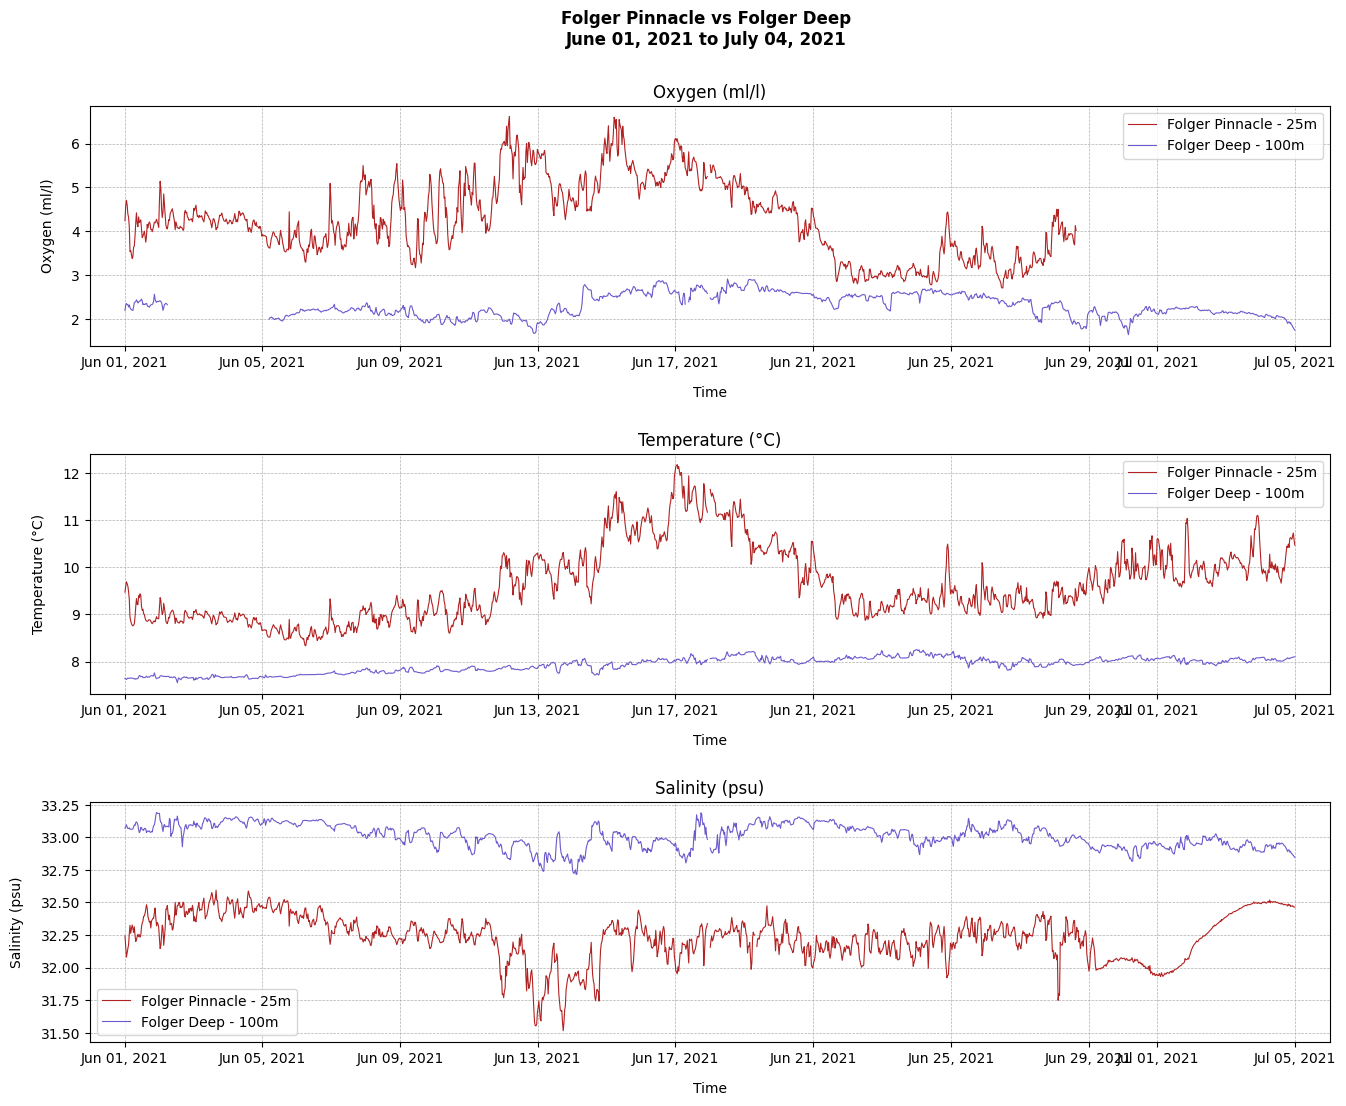

In [50]:
# Write your code to examine the impacts of the heat wave here

# Define time period of interest
jun_str = "2021-06-01T00:00:00.000Z"
jul_str = "2021-07-05T00:00:00.000Z"

# Convert dates to Timestamp objects
jun = pandas.to_datetime(jun_str)
jul = pandas.to_datetime(jul_str)

# Create new DataFrames by slicing the original
pin_heat = pin_yr_21_indicators.loc[jun:jul]  
deep_heat = deep_yr_21_indicators.loc[jun:jul]  

# Investigate the new DataFrame to confirm slicing went correctly

# Graph your results
onc_plotting.compare_sensor_subplots(df1=deep_heat, df2=pin_heat, sensor_cols=["Oxygen (ml/l)", "Temperature (°C)", "Salinity (psu)"], location_code1=deep_locationCode, location_code2=pinnacle_locationCode)

## 5\.2 Challenge: Investigate tidal signals

You may have noticed the presence of daily fluctuations on many of the above graphs\. These are likely related to the tides, which follow 12 and 24 hour long cycles\. Try slicing a short segment of data \(a week would work well\), and graphing the results\. Can you see the tides? Which variables show tides?

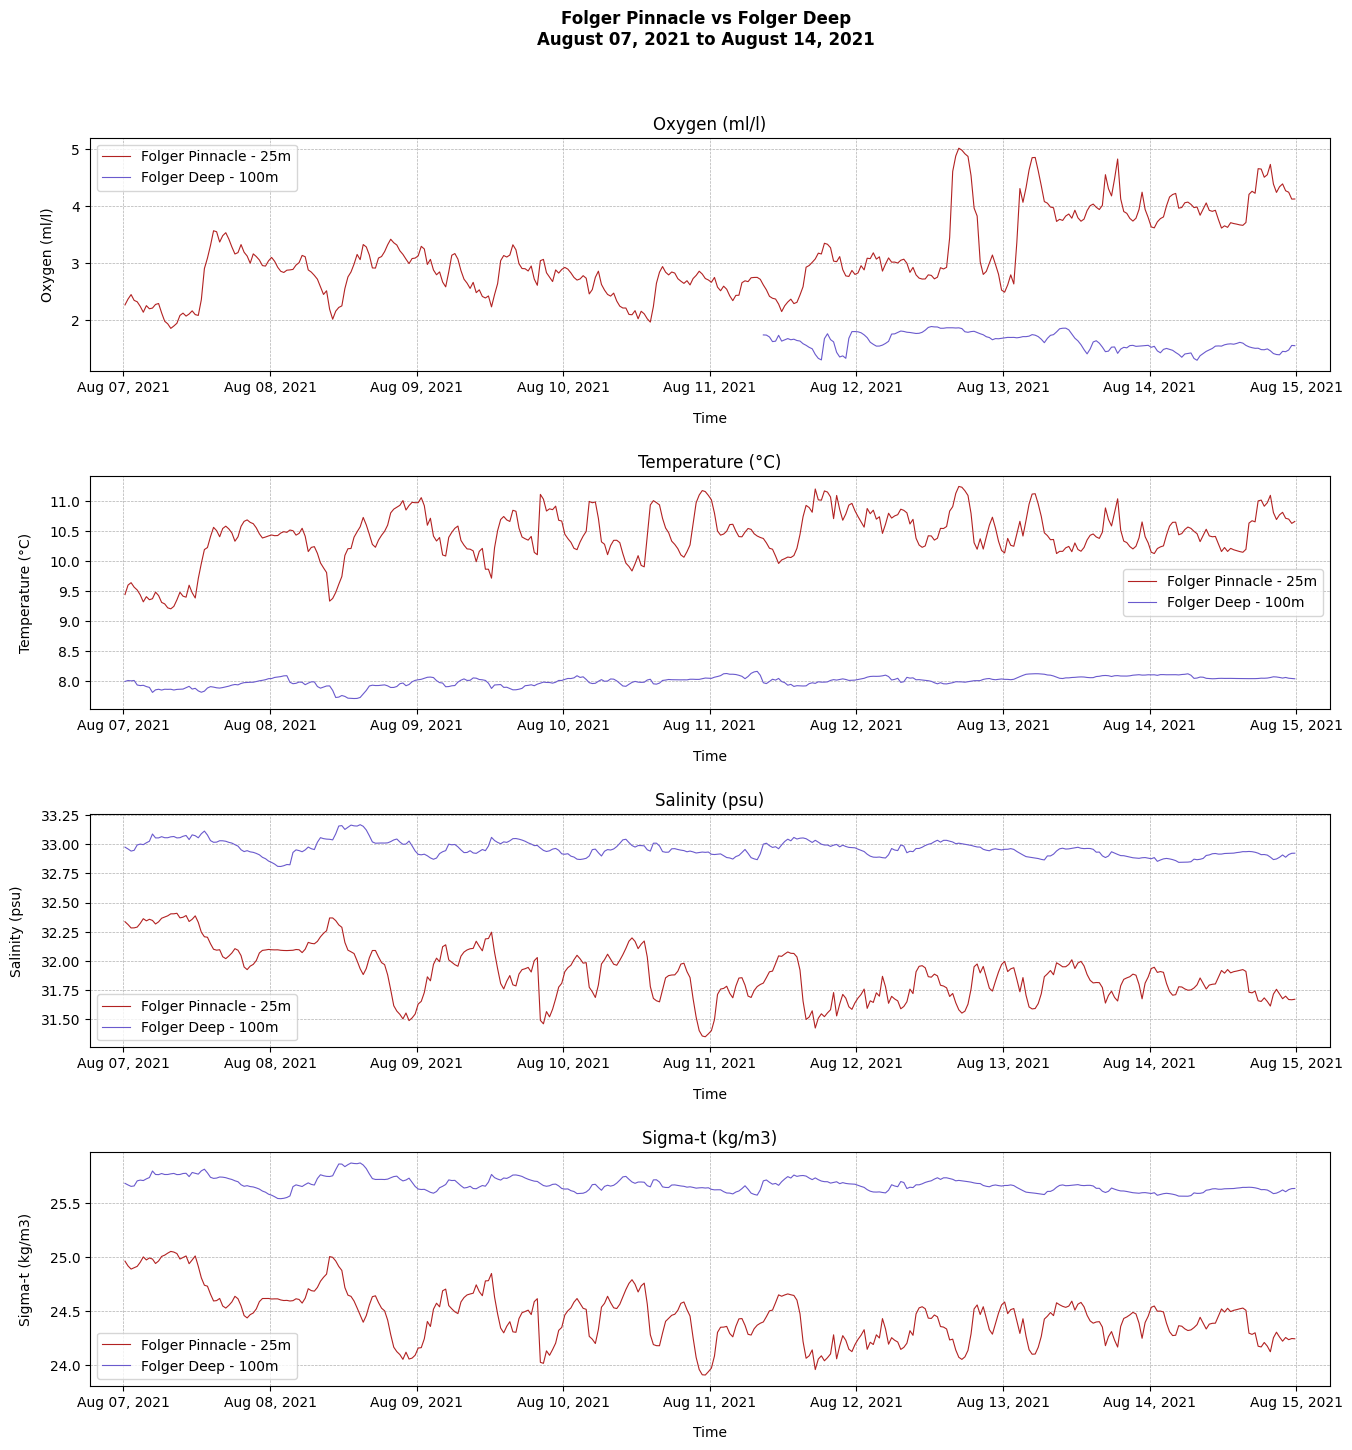

In [63]:
# write your code to examine the effects of the tides here

# Define time period of interest
week_start_str = "2021-08-07T00:00:00.000Z"
week_end_str = "2021-08-15T00:00:00.000Z"

# Convert dates to Timestamp objects
week_start = pandas.to_datetime(week_start_str)
week_end = pandas.to_datetime(week_end_str)

# Create new DataFrames by slicing the original
pin_week = pin_yr_21_indicators.loc[week_start:week_end]  
deep_week = deep_yr_21_indicators.loc[week_start:week_end]  

# Investigate the new DataFrame to confirm slicing went correctly

# Graph your results
onc_plotting.compare_sensor_subplots(df1=deep_week, df2=pin_week, sensor_cols=["Oxygen (ml/l)", "Temperature (°C)", "Salinity (psu)", "Sigma-t (kg/m3)"], location_code1=deep_locationCode, location_code2=pinnacle_locationCode)

## 5\.3 Challenge: Compare Folger Passage with other locations

Try to replicate the graphs above with another location offshore of Folger Passage\. Barkley Canyon is located on the continental shelf and slope break, with sensors at depths ranging from 400 to 900 m and has several locations which can be analyzed\. Below are location and property codes for two of these locations: try creating a DataFrame for one or more of them, and comparing the data with Folger Passage\. What do you notice? Does the deep canyon show the same trends or periods of interest as Folger?

<img src="image-20260708-151750.png" width="" align="" />

You can also try comparing Folger Passage to other shallow\-water locations: ONC has shallow water observatories in the Salish Sea, including one at Burrard Inlet \(28 m depth\) and one at Campbell River \(8 m depth\)\. These might be good locations to observe the June heat wave — be careful to keep track of the scale of the temperature axis, as these shallow observatories have much higher variability in temperature than Folger, which could make a difference of one degree look smaller\!

In [52]:
# Location Codes for Barkley Canyon
# See documentation - https://wiki.oceannetworks.ca/x/gYLyAg
# Type: string
upperslope_locationCode = "NCBC" 
axis_locationCode = "BACAX" 

# Properties available at Barkley Canyon
# See documentation - https://wiki.oceannetworks.ca/x/2w7nAg
# Type: list of strings
upperslope_properties = ["oxygen", "salinity", "seawatertemperature", "density", "sigmat"]
axis_properties = ["oxygen", "salinity", "seawatertemperature", "density", "sigmat", "chlorophyll", "turbidityntu"]

In [53]:
# Location Codes for Salish Sea
# See documentation - https://wiki.oceannetworks.ca/x/gYLyAg
# Type: string
burrard_inlet_locationCode = "BIIP" 
campbell_river_locationCode = "CRIP" 

# Properties available at Barkley Canyon
# See documentation - https://wiki.oceannetworks.ca/x/2w7nAg
# Type: list of strings
burrard_inlet_properties = ["oxygen", "salinity", "seawatertemperature", "sigmat", "chlorophyll", "turbidityntu"]
campbell_river_properties = ["oxygen", "salinity", "seawatertemperature", "density", "sigmat", "chlorophyll", "turbidityntu"]

In [54]:
# create your dataframe for the location, date, and variables you want
upperslope_indicators = onc_client.get_multi_property_dataframe(
    start=start_date,                    # Start date; Format: "YYYY-mm-DDTHH:MM:SS.fffZ" 
    end=end_date,                      # End date; Format: "YYYY-mm-DDTHH:MM:SS.fffZ"                     
    location_code=upperslope_locationCode,   # Location code   
    property_codes=upperslope_properties,    # List of parameters to request.     
    resample=resample,                 # Time interval (in seconds) to average data
    updates=True                       # Set to True to print API request status and progress
    )

API Request: getScalardata{'locationCode': 'NCBC', 'deviceCategoryCode': 'OXYSENSOR', 'propertyCode': 'oxygen', 'dateFrom': '2021-01-01T00:00:00.000Z', 'dateTo': '2022-01-01T00:00:00.000Z', 'metadata': 'minimum', 'qualityControl': 'clean', 'resamplePeriod': 1800, 'resampleType': 'avg', 'sensorCategoryCodes': 'oxygen_corrected'}
API Request: getScalardata{'locationCode': 'NCBC', 'deviceCategoryCode': 'CTD', 'propertyCode': 'salinity', 'dateFrom': '2021-01-01T00:00:00.000Z', 'dateTo': '2022-01-01T00:00:00.000Z', 'metadata': 'minimum', 'qualityControl': 'clean', 'resamplePeriod': 1800, 'resampleType': 'avg'}
API Request: getScalardata{'locationCode': 'NCBC', 'deviceCategoryCode': 'CTD', 'propertyCode': 'seawatertemperature', 'dateFrom': '2021-01-01T00:00:00.000Z', 'dateTo': '2022-01-01T00:00:00.000Z', 'metadata': 'minimum', 'qualityControl': 'clean', 'resamplePeriod': 1800, 'resampleType': 'avg'}
API Request: getScalardata{'locationCode': 'NCBC', 'deviceCategoryCode': 'CTD', 'propertyCode

In [55]:
upperslope_indicators

,Oxygen (ml/l),Salinity (psu),Temperature (°C),Density (kg/m3),Sigma-t (kg/m3)
Time,,,,,
2021-02-10 22:45:00+00:00,NaN,NaN,NaN,NaN,NaN
2021-02-10 23:15:00+00:00,1.073079,34.040158,5.500694,1028.684180,26.855586
2021-02-10 23:45:00+00:00,1.047835,34.043229,5.469843,1028.689072,26.861718
2021-02-11 00:15:00+00:00,1.034198,34.045176,5.450748,1028.691631,26.865544
2021-02-11 00:45:00+00:00,1.044655,34.043260,5.468416,1028.686680,26.861913
...,...,...,...,...,...
2021-12-31 21:45:00+00:00,1.098786,34.023146,5.246151,1028.701146,26.872309
2021-12-31 22:15:00+00:00,1.105851,34.022021,5.251483,1028.697853,26.870794
2021-12-31 22:45:00+00:00,1.108259,34.021869,5.251072,1028.696238,26.870722


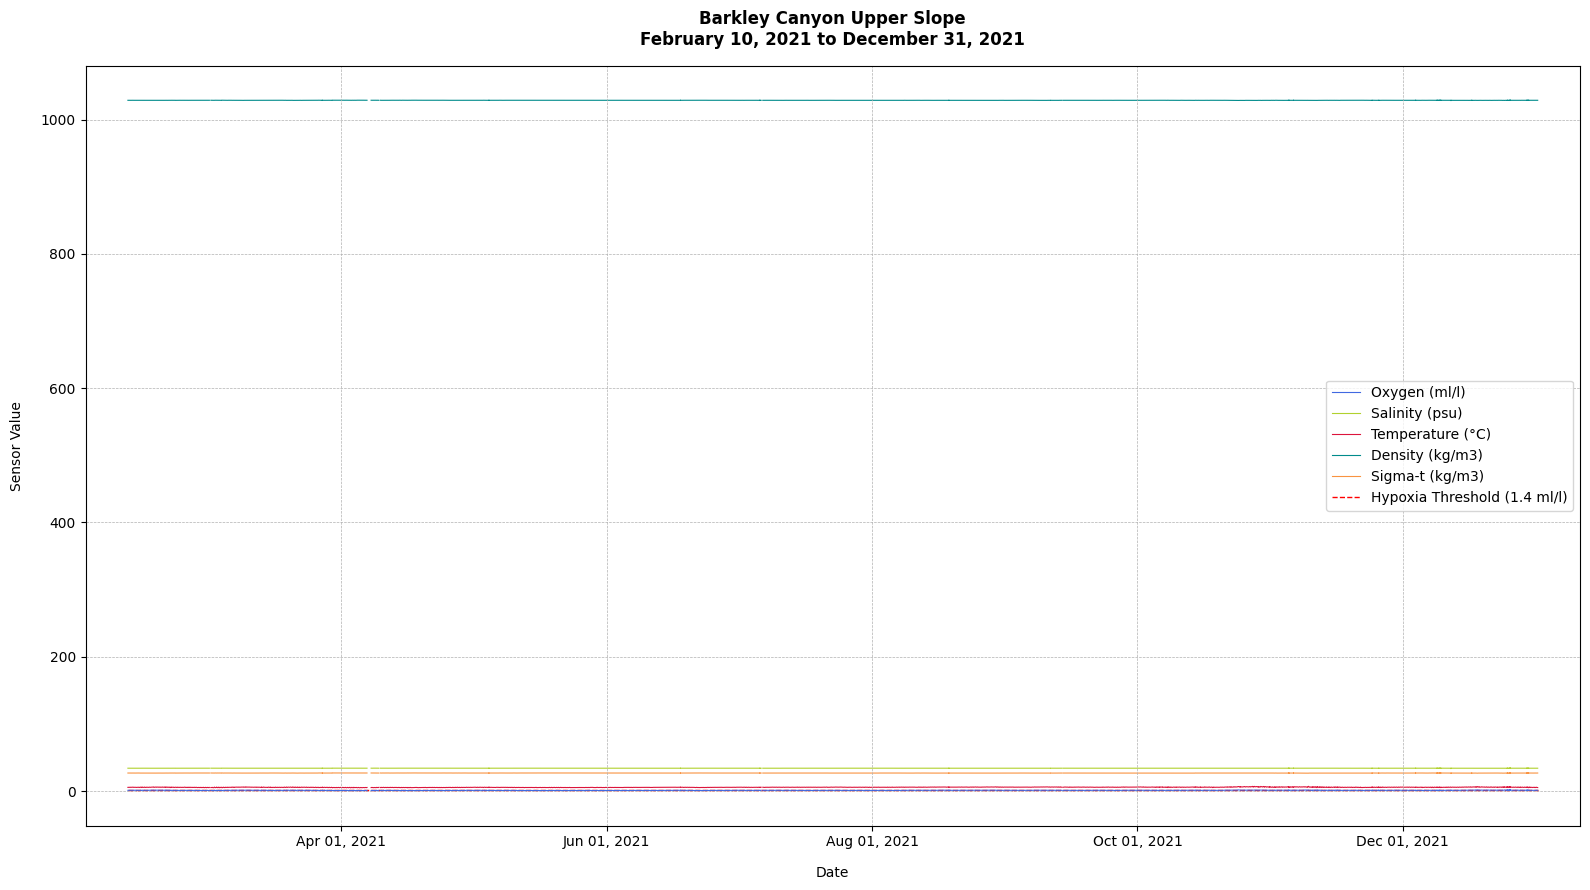

In [56]:
onc_plotting.plot_dataframe(df=upperslope_indicators, location_code=upperslope_locationCode)

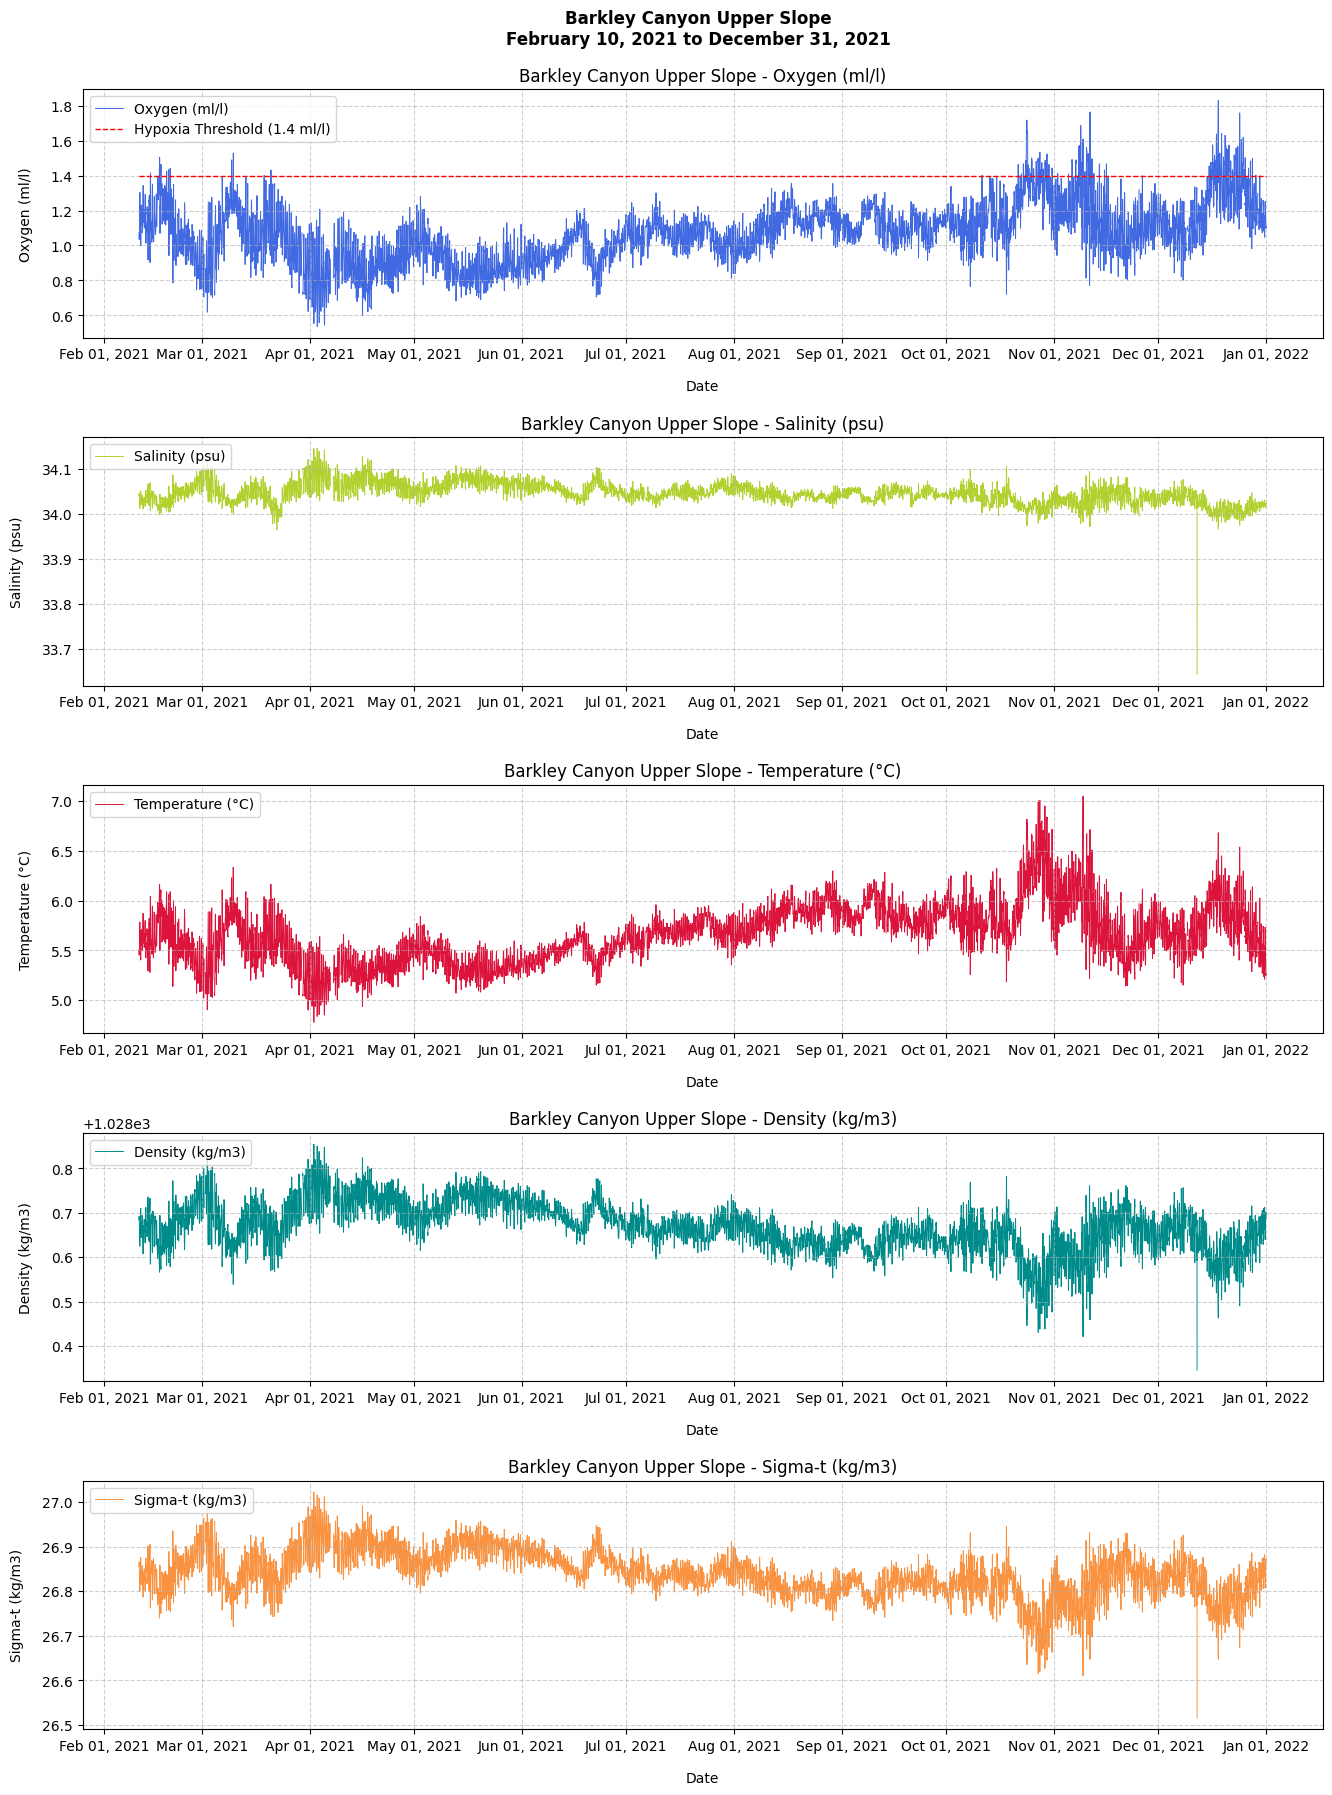

In [57]:
onc_plotting.subplot_all_with_time(df=upperslope_indicators, location_code=upperslope_locationCode)

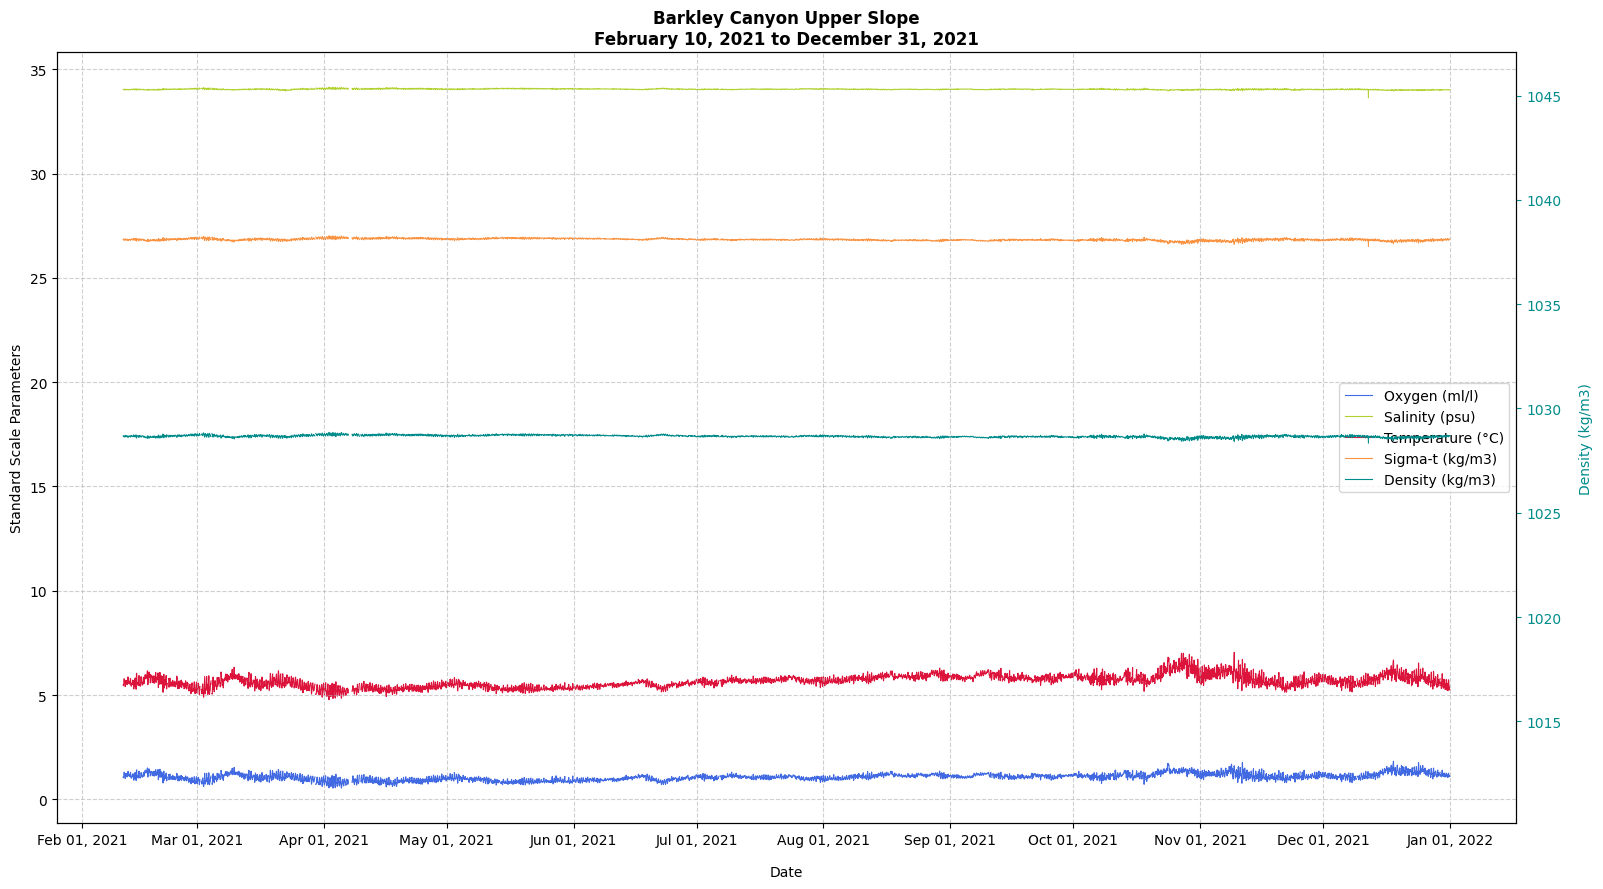

In [58]:
onc_plotting.plot_with_twin_y_axis_for_outlier(df=upperslope_indicators, location_code=upperslope_locationCode)

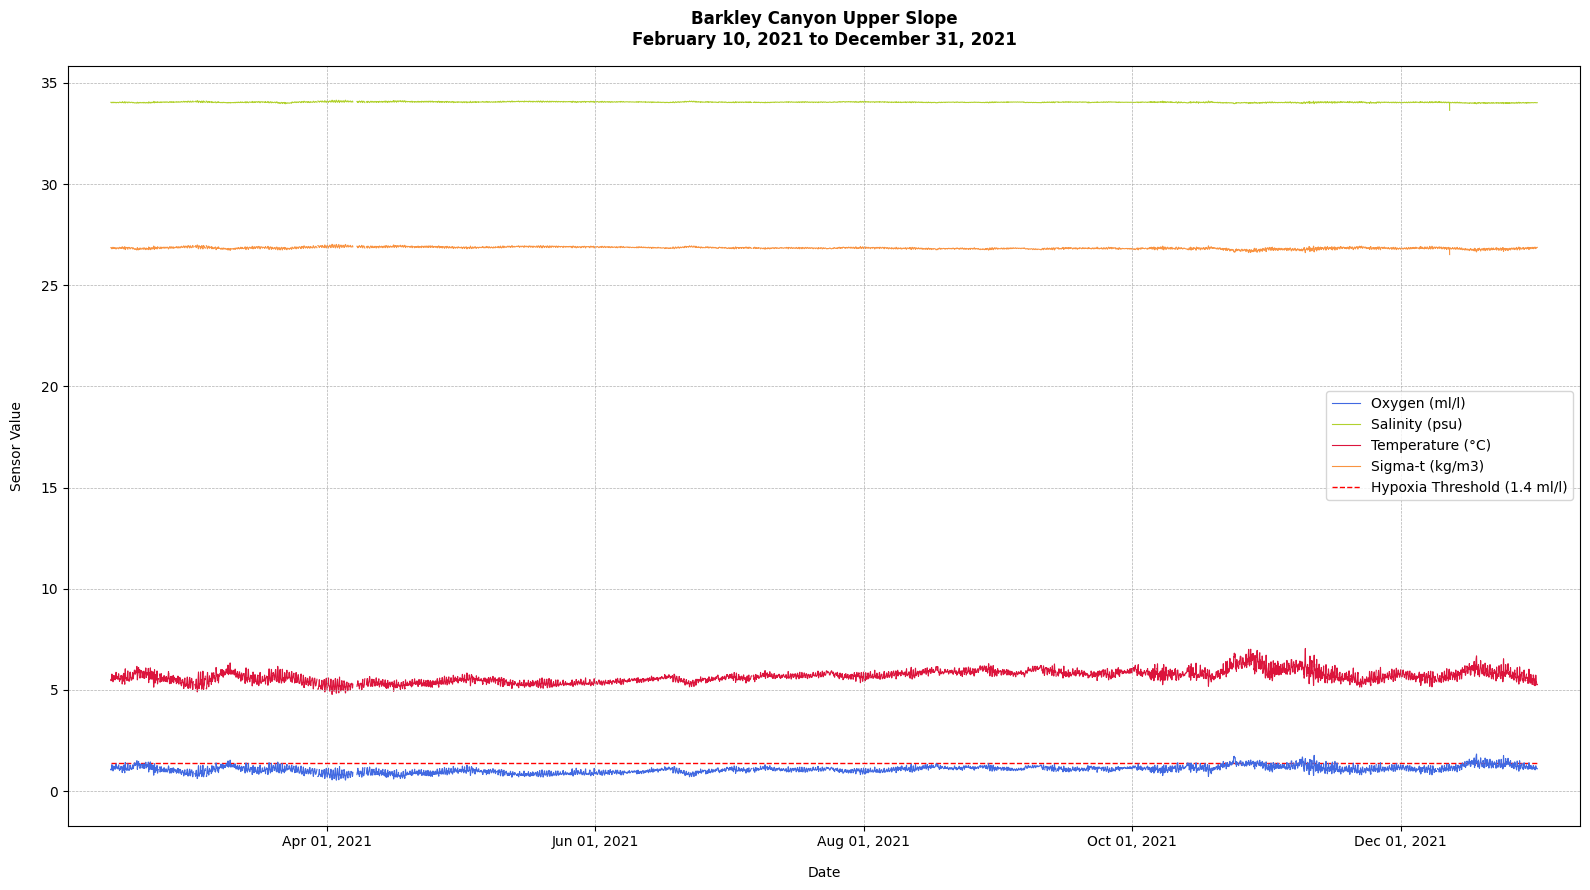

In [59]:
upperslope_indicators.drop("Density (kg/m3)", axis=1, inplace=True) 
onc_plotting.plot_dataframe(df=upperslope_indicators, location_code=upperslope_locationCode)

# 6 Conclusion

In this notebook, we've requested data from ONC's API, investigated it in a DataFrame, and plotted it in several ways\. We've compared the time series from ONC's Folger passage observatories to published results in the same region, and we've encountered some difficulties in analyzing this data, such as issues with instruments and vastly different scales of values\.

Feel free to try more things in this notebook before moving on to the next one\!

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=060e24c8-1a84-4077-8eb9-09102bf2444a' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>